# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

## 1. Imports & Configuration

In [177]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import lightgbm as lgb

# Counterfactual Explanation packages
import dice_ml
import alibi
from alibi.explainers import PartialDependence, plot_pd
from alibi.explainers import CounterfactualProto
import tensorflow as tf

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

# Additional packages
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import shap
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\wb_allegro\data
Models directory: C:\wb_allegro\models


## 2. Data Loading & Initial EDA

Make sure you have downloaded the data from Kaggle into the `data/` directory.
See the README for download instructions.

In [178]:
# Download the dataset using Kaggle API
kaggle_dataset = "home-credit-default-risk"
output_dir = DATA_DIR

output_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    ["kaggle", "competitions", "download", "-c", kaggle_dataset, "-p", str(output_dir)],
    check=True,
)

# Unzip the downloaded archive

zip_path = output_dir / f"{kaggle_dataset}.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(output_dir)

zip_path.unlink()
print(f"Data downloaded and extracted to {output_dir}")

Data downloaded and extracted to C:\wb_allegro\data


In [179]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")

print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")
app_train.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [180]:
# Quick overview of missing values
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

Columns with >50% missing:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG      

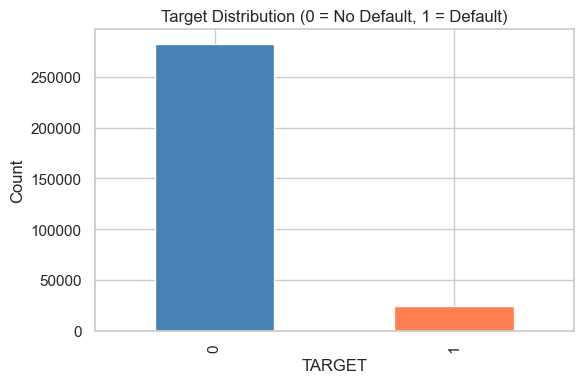

In [181]:
# Target distribution visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
app_train[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Distribution (0 = No Default, 1 = Default)")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [182]:
# Correlation analysis for numeric variables (without index variable)
numeric_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "SK_ID_CURR"]    

target_correlations = (
    app_train[numeric_cols]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_summary = pd.DataFrame({
    "correlation_with_target": target_correlations,
    "abs_correlation": target_correlations.abs(),
    "missing_percentage": app_train[target_correlations.index].isnull().mean().values * 100,
})

print("Top 10 numeric features most correlated with the target:")
print(corr_summary.head(10).round(4))

Top 10 numeric features most correlated with the target:
                             correlation_with_target  abs_correlation  \
EXT_SOURCE_3                                 -0.1789           0.1789   
EXT_SOURCE_2                                 -0.1605           0.1605   
EXT_SOURCE_1                                 -0.1553           0.1553   
DAYS_BIRTH                                    0.0782           0.0782   
REGION_RATING_CLIENT_W_CITY                   0.0609           0.0609   
REGION_RATING_CLIENT                          0.0589           0.0589   
DAYS_LAST_PHONE_CHANGE                        0.0552           0.0552   
DAYS_ID_PUBLISH                               0.0515           0.0515   
REG_CITY_NOT_WORK_CITY                        0.0510           0.0510   
FLAG_EMP_PHONE                                0.0460           0.0460   

                             missing_percentage  
EXT_SOURCE_3                            19.8253  
EXT_SOURCE_2                           

In [183]:
# Most correlated features explanations from Kaggle dataset description
#EXT_SOURCE_3 - Normalized score from external data source                           
#EXT_SOURCE_2 - Normalized score from external data source                            
#EXT_SOURCE_1 - Normalized score from external data source                             
#DAYS_BIRTH - Client's age in days at the time of application, time only relative to the application                       
#REGION_RATING_CLIENT_W_CITY - Our rating of the region where client lives with taking city into account (1,2,3)           
#REGION_RATING_CLIENT - Our rating of the region where client lives (1,2,3)                   
#DAYS_LAST_PHONE_CHANGE - How many days before application did client change phone number               
#DAYS_ID_PUBLISH  - How many days before the application did client change the identity document with which he applied                       
#REG_CITY_NOT_WORK_CITY - Flag if client's permanent address does not match work address (1=different, 0=same, at city level)               
#FLAG_EMP_PHONE - Did client provide work phone (1=YES, 0=NO)                      

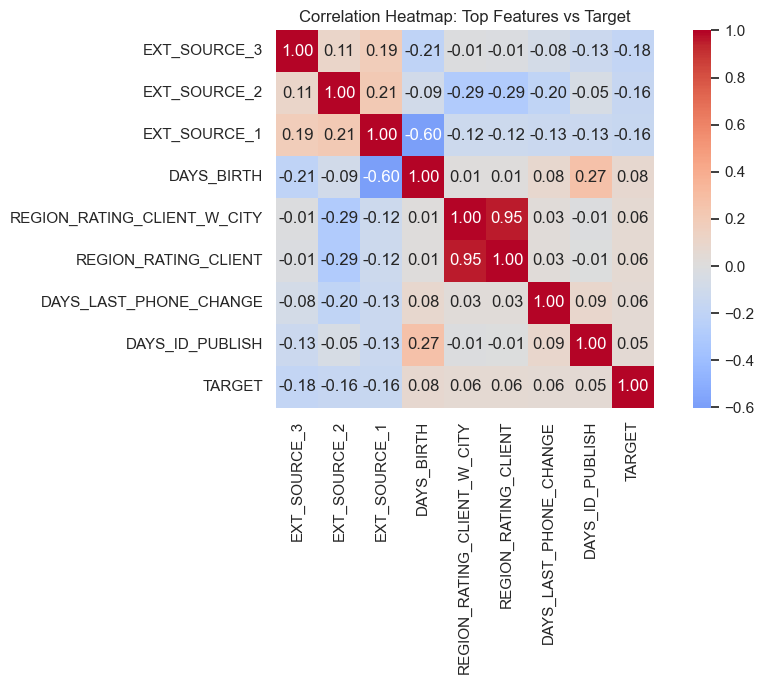

In [184]:
# Heatmap for the strongest numeric relationships
top_corr_features = target_correlations.head(8).index.tolist()
heatmap_features = top_corr_features + [TARGET_COLUMN]

plt.figure(figsize=(10, 7))
sns.heatmap(
    app_train[heatmap_features].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Heatmap: Top Features vs Target")
plt.tight_layout()
plt.show()

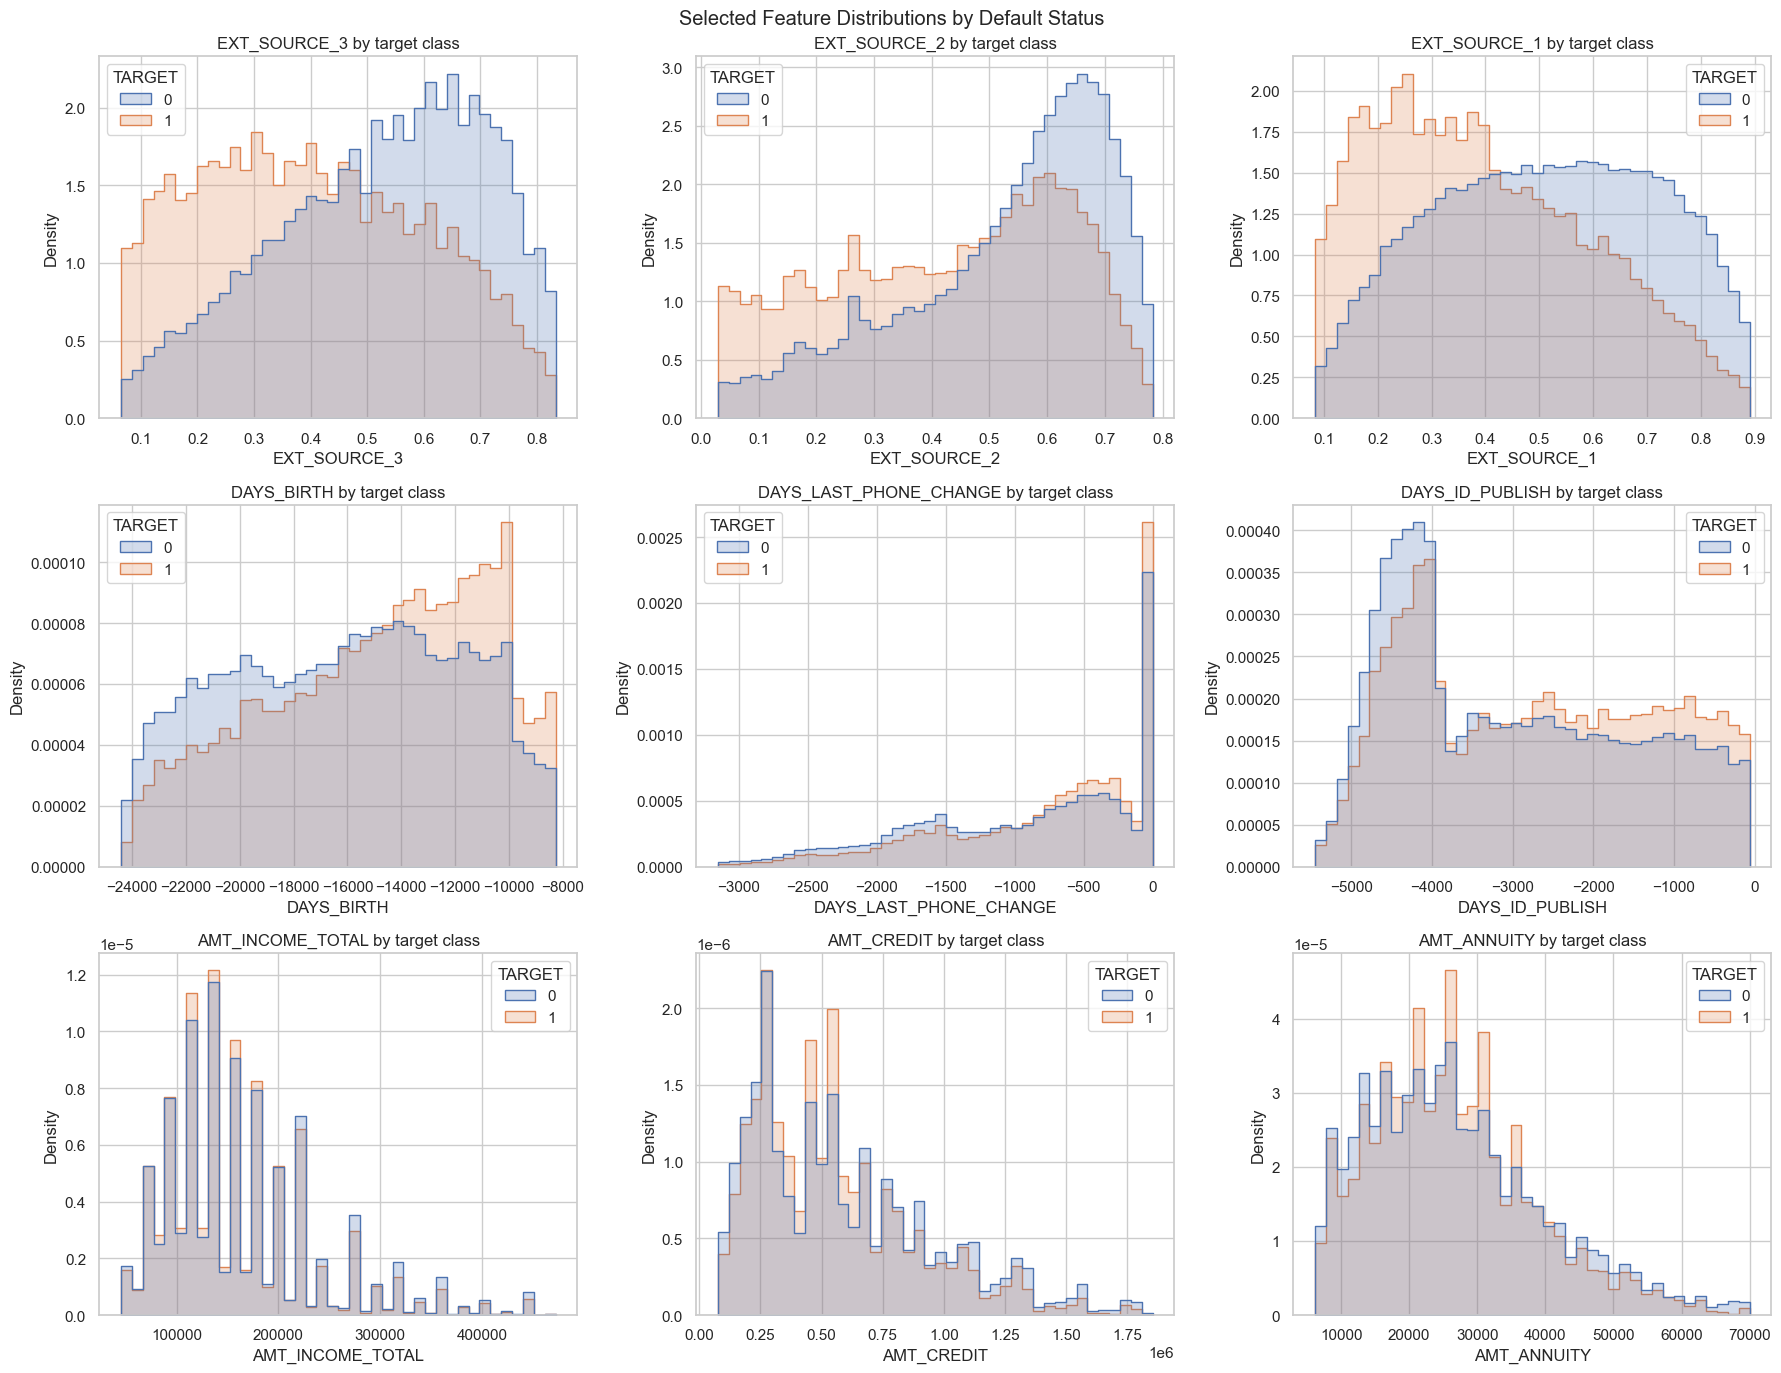

In [185]:
# Distribution plots for selected features by target class
candidate_features = [
    "EXT_SOURCE_3",
    "EXT_SOURCE_2",
    "EXT_SOURCE_1",
    "DAYS_BIRTH",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_ID_PUBLISH",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, feature in zip(axes, candidate_features):
    plot_data = app_train[[feature, TARGET_COLUMN]].dropna().copy()

    lower = plot_data[feature].quantile(0.01)
    upper = plot_data[feature].quantile(0.99)
    
    plot_data = plot_data[(plot_data[feature] >= lower) & (plot_data[feature] <= upper)]

    sns.histplot(
        data=plot_data,
        x=feature,
        hue=TARGET_COLUMN,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax
    )
    ax.set_title(f"{feature} by target class")
    ax.set_xlabel(feature)

plt.suptitle("Selected Feature Distributions by Default Status")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Create new features with **semantic, human-readable names**.

Example naming conventions:
- `income_to_credit_ratio` (not `feat_001`)
- `annuity_to_income_ratio` (not `ratio_2`)
- `bureau_active_credits_count` (not `bur_cnt`)

In [186]:
# Loading supplementary tables
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")
previous_app = pd.read_csv(DATA_DIR / "previous_application.csv")
pos_cash = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
credit_card = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

In [187]:
# Overview of supplementary tables
table_overview = pd.DataFrame([
    {"table_name": "bureau",
     "rows": bureau.shape[0],
     "columns": bureau.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_BUREAU",
     "granularity": "One row per previous external credit record",
     "description": "Past credits reported by other financial institutions."},
    {"table_name": "bureau_balance",
     "rows": bureau_balance.shape[0],
     "columns": bureau_balance.shape[1],
     "join_key": "SK_ID_BUREAU",
     "granularity": "Monthly history of bureau credits",
     "description": "Status history for credits listed in bureau."},
    {"table_name": "previous_application",
     "rows": previous_app.shape[0],
     "columns": previous_app.shape[1],
     "join_key": "SK_ID_CURR",
     "granularity": "One row per previous Home Credit application",
     "description": "Application data of client's previous loan applications in Home Credit."},
    {"table_name": "POS_CASH_balance",
     "rows": pos_cash.shape[0],
     "columns": pos_cash.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "Monthly balance of POS and cash loans",
     "description": "Monthly snapshots of POS and cash loan accounts."},
    {"table_name": "installments_payments",
     "rows": installments.shape[0],
     "columns": installments.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "One row per installment payment",
     "description": "Repayment history for previously granted loans."},
    {"table_name": "credit_card_balance",
      "rows": credit_card.shape[0],
     "columns": credit_card.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "Monthly credit card balance snapshot",
     "description": "Monthly balance and usage information for credit cards."},
])

display(table_overview)

,table_name,rows,columns,join_key,granularity,description
0,bureau,1716428,17,"SK_ID_CURR, SK_ID_BUREAU",One row per previous external credit record,Past credits reported by other financial insti...
1,bureau_balance,27299925,3,SK_ID_BUREAU,Monthly history of bureau credits,Status history for credits listed in bureau.
2,previous_application,1670214,37,SK_ID_CURR,One row per previous Home Credit application,Application data of client's previous loan app...
3,POS_CASH_balance,10001358,8,"SK_ID_CURR, SK_ID_PREV",Monthly balance of POS and cash loans,Monthly snapshots of POS and cash loan accounts.
4,installments_payments,13605401,8,"SK_ID_CURR, SK_ID_PREV",One row per installment payment,Repayment history for previously granted loans.
5,credit_card_balance,3840312,23,"SK_ID_CURR, SK_ID_PREV",Monthly credit card balance snapshot,Monthly balance and usage information for cred...


In [188]:
app_train["DAYS_EMPLOYED"].max()

365243

In [189]:
## Feature engineering: main table
df = app_train.copy()

def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

# Some records use 365243 as a placeholder for missing employment duration
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# More intuitive time-based variables
df["age_years"] = (-df["DAYS_BIRTH"]) / 365.25
df["employment_years"] = (-df["DAYS_EMPLOYED_CLEAN"]) / 365.25
df["employment_to_age_ratio"] = safe_divide(df["employment_years"], df["age_years"])

# Affordability ratios
df["income_to_credit_ratio"] = safe_divide(df["AMT_INCOME_TOTAL"], df["AMT_CREDIT"])
df["annuity_to_income_ratio"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
df["credit_to_goods_ratio"] = safe_divide(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
df["credit_to_annuity_ratio"] = safe_divide(df["AMT_CREDIT"], df["AMT_ANNUITY"])

# Household-level scaling
df["income_per_family_member"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])
df["credit_per_family_member"] = safe_divide(df["AMT_CREDIT"], df["CNT_FAM_MEMBERS"])
df["income_per_child"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_CHILDREN"])

# External score aggregation
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

df["external_sources_mean"] = df[ext_cols].mean(axis=1)
df["external_sources_std"] = df[ext_cols].std(axis=1)
df["external_sources_min"] = df[ext_cols].min(axis=1)
df["external_sources_max"] = df[ext_cols].max(axis=1)
df["external_sources_count"] = df[ext_cols].notnull().sum(axis=1)

# Counts of binary flags often used as simple stability / documentation proxies
document_flag_cols = [col for col in df.columns if col.startswith("FLAG_DOCUMENT_")]
contact_flag_cols = ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]

df["document_flags_count"] = df[document_flag_cols].sum(axis=1)
df["contact_flags_count"] = df[contact_flag_cols].sum(axis=1)

print(f"Shape after main-table feature engineering: {df.shape}")

Shape after main-table feature engineering: (307511, 140)


In [190]:
bureau_balance["STATUS"].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [191]:
## Feature engineering: bureau_balance + bureau
# bureau_balance contains monthly status history for bureau loans
bb = bureau_balance.copy()

# Mapping monthly status to numeric scale
# X = no loan information for the month, C = closed, 0 = current, 1-5 = increasing delinquency
status_mapping = {
    "X": np.nan,
    "C": 0,
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
}
bb["status_numeric"] = bb["STATUS"].map(status_mapping)
bb["is_closed_month"] = (bb["STATUS"] == "C").astype(int)
bb["is_current_month"] = (bb["STATUS"] == "0").astype(int)
bb["is_delinquent_month"] = bb["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)

bureau_balance_agg = bb.groupby("SK_ID_BUREAU").agg(
    bureau_balance_month_count=("MONTHS_BALANCE", "size"),
    bureau_balance_mean_status=("status_numeric", "mean"),
    bureau_balance_max_status=("status_numeric", "max"),
    bureau_balance_bad_status_share=("is_delinquent_month", "mean"),
    bureau_balance_closed_month_share=("is_closed_month", "mean"),
    bureau_balance_current_month_share=("is_current_month", "mean"),
).reset_index()

# Merge monthly bureau history into bureau table
bureau_fe = bureau.copy()
bureau_fe = bureau_fe.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")

bureau_fe["is_active_credit"] = (bureau_fe["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_fe["is_closed_credit"] = (bureau_fe["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau_fe["has_credit_overdue"] = (bureau_fe["CREDIT_DAY_OVERDUE"] > 0).astype(int)

bureau_agg = bureau_fe.groupby("SK_ID_CURR").agg(
    bureau_loan_count=("SK_ID_BUREAU", "nunique"),
    bureau_active_loan_count=("is_active_credit", "sum"),
    bureau_closed_loan_count=("is_closed_credit", "sum"),
    bureau_total_credit_sum=("AMT_CREDIT_SUM", "sum"),
    bureau_total_debt_sum=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_total_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_max_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "max"),
    bureau_any_overdue=("has_credit_overdue", "max"),
    bureau_mean_days_since_credit=("DAYS_CREDIT", lambda s: (-s).mean()),
    bureau_max_days_since_credit=("DAYS_CREDIT", lambda s: (-s).max()),
    bureau_mean_credit_prolong_count=("CNT_CREDIT_PROLONG", "mean"),
    bureau_balance_mean_status=("bureau_balance_mean_status", "mean"),
    bureau_balance_max_status=("bureau_balance_max_status", "max"),
    bureau_balance_bad_status_share=("bureau_balance_bad_status_share", "mean"),
).reset_index()

bureau_agg["bureau_active_loan_share"] = safe_divide(bureau_agg["bureau_active_loan_count"], bureau_agg["bureau_loan_count"])
bureau_agg["bureau_debt_to_credit_ratio"] = safe_divide(bureau_agg["bureau_total_debt_sum"], bureau_agg["bureau_total_credit_sum"])
bureau_agg["bureau_overdue_to_debt_ratio"] = safe_divide(bureau_agg["bureau_total_overdue_sum"], bureau_agg["bureau_total_debt_sum"])

print(f"bureau_agg shape: {bureau_agg.shape}")
bureau_agg.head()

bureau_agg shape: (305811, 18)


,SK_ID_CURR,bureau_loan_count,bureau_active_loan_count,bureau_closed_loan_count,bureau_total_credit_sum,bureau_total_debt_sum,bureau_total_overdue_sum,bureau_max_overdue_sum,bureau_any_overdue,bureau_mean_days_since_credit,bureau_max_days_since_credit,bureau_mean_credit_prolong_count,bureau_balance_mean_status,bureau_balance_max_status,bureau_balance_bad_status_share,bureau_active_loan_share,bureau_debt_to_credit_ratio,bureau_overdue_to_debt_ratio
0,100001,7,3,4,1453365.000,596686.5,0.0,0.0,0,735.000000,1572,0.0,0.010989,1.0,0.007519,0.428571,0.410555,0.0
1,100002,8,2,6,865055.565,245781.0,0.0,0.0,0,874.000000,1437,0.0,0.299222,1.0,0.255682,0.250000,0.284122,0.0
2,100003,4,1,3,1017400.500,0.0,0.0,0.0,0,1400.750000,2586,0.0,NaN,NaN,NaN,0.250000,0.000000,NaN
3,100004,2,0,2,189037.800,0.0,0.0,0.0,0,867.000000,1326,0.0,NaN,NaN,NaN,0.000000,0.000000,NaN
4,100005,3,2,1,657126.000,568408.5,0.0,0.0,0,190.666667,373,0.0,0.000000,0.0,0.000000,0.666667,0.864992,0.0


In [192]:
previous_app["NAME_CONTRACT_STATUS"].unique()

array(['Approved', 'Refused', 'Canceled', 'Unused offer'], dtype=object)

In [193]:
app_train["NAME_INCOME_TYPE"].unique()

array(['Working', 'State servant', 'Commercial associate', 'Pensioner',
       'Unemployed', 'Student', 'Businessman', 'Maternity leave'],
      dtype=object)

In [194]:
## Feature engineering: previous_application
prev = previous_app.copy()

# Status flags - approved and refuesed
prev["is_approved"] = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["is_refused"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)

# Additional status flags
prev["is_canceled"] = (prev["NAME_CONTRACT_STATUS"] == "Canceled").astype(int)
prev["is_unused_offer"] = (prev["NAME_CONTRACT_STATUS"] == "Unused offer").astype(int)

# Ratio features
prev["application_to_credit_ratio"] = safe_divide(prev["AMT_APPLICATION"], prev["AMT_CREDIT"])
prev["down_payment_to_credit_ratio"] = safe_divide(prev["AMT_DOWN_PAYMENT"], prev["AMT_CREDIT"])

# Additional amount and contract structure features
prev["credit_minus_application"] = prev["AMT_CREDIT"] - prev["AMT_APPLICATION"]
prev["credit_to_goods_ratio"] = safe_divide(prev["AMT_CREDIT"], prev["AMT_GOODS_PRICE"])
prev["annuity_to_credit_ratio"] = safe_divide(prev["AMT_ANNUITY"], prev["AMT_CREDIT"])
prev["goods_to_application_ratio"] = safe_divide(prev["AMT_GOODS_PRICE"], prev["AMT_APPLICATION"])

# Proxy for how expensive the previous credit was in total
prev["total_repayment_to_credit_ratio"] = safe_divide(prev["AMT_ANNUITY"] * prev["CNT_PAYMENT"], prev["AMT_CREDIT"])

# Product-type flags
prev["is_cash_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Cash loans").astype(int)
prev["is_consumer_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Consumer loans").astype(int)
prev["is_revolving_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Revolving loans").astype(int)

# Application-process flags
prev["is_last_application_per_contract"] = (prev["FLAG_LAST_APPL_PER_CONTRACT"] == "Y").astype(int)
prev["is_last_application_in_day"] = prev["NFLAG_LAST_APPL_IN_DAY"].fillna(0).astype(int)
prev["is_insured_on_approval"] = prev["NFLAG_INSURED_ON_APPROVAL"].fillna(0)

# Clean placeholder dates
prev_day_cols = [
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
]

for col in prev_day_cols:
    prev[col] = prev[col].replace(365243, np.nan)

# Contract timeline features
prev["days_to_first_due_after_decision"] = prev["DAYS_FIRST_DUE"] - prev["DAYS_DECISION"]
prev["planned_contract_length_days"] = prev["DAYS_LAST_DUE_1ST_VERSION"] - prev["DAYS_FIRST_DUE"]
prev["actual_contract_length_days"] = prev["DAYS_LAST_DUE"] - prev["DAYS_FIRST_DUE"]
prev["decision_to_termination_days"] = prev["DAYS_TERMINATION"] - prev["DAYS_DECISION"]

# Negative intervals are not meaningful here -> set to missing
interval_cols = [
    "days_to_first_due_after_decision",
    "planned_contract_length_days",
    "actual_contract_length_days",
    "decision_to_termination_days",
]

for col in interval_cols:
    prev.loc[prev[col] < 0, col] = np.nan

# Aggregation per one loan from main table
previous_agg = prev.groupby("SK_ID_CURR").agg(
    previous_application_count=("SK_ID_PREV", "nunique"),
    previous_approved_count=("is_approved", "sum"),
    previous_refused_count=("is_refused", "sum"),
    previous_mean_application_amount=("AMT_APPLICATION", "mean"),
    previous_mean_credit_amount=("AMT_CREDIT", "mean"),
    previous_mean_annuity=("AMT_ANNUITY", "mean"),
    previous_mean_down_payment=("AMT_DOWN_PAYMENT", "mean"),
    previous_mean_application_to_credit_ratio=("application_to_credit_ratio", "mean"),
    previous_mean_down_payment_to_credit_ratio=("down_payment_to_credit_ratio", "mean"),
    previous_mean_payment_count=("CNT_PAYMENT", "mean"),
    previous_mean_days_since_decision=("DAYS_DECISION", lambda s: (-s).mean()),
    previous_canceled_count=("is_canceled", "sum"),
    previous_unused_offer_count=("is_unused_offer", "sum"),
    previous_cash_loan_share=("is_cash_loan", "mean"),
    previous_consumer_loan_share=("is_consumer_loan", "mean"),
    previous_revolving_loan_share=("is_revolving_loan", "mean"),
    previous_mean_goods_price=("AMT_GOODS_PRICE", "mean"),
    previous_mean_down_payment_rate=("RATE_DOWN_PAYMENT", "mean"),
    previous_mean_credit_minus_application=("credit_minus_application", "mean"),
    previous_mean_credit_to_goods_ratio=("credit_to_goods_ratio", "mean"),
    previous_mean_annuity_to_credit_ratio=("annuity_to_credit_ratio", "mean"),
    previous_mean_goods_to_application_ratio=("goods_to_application_ratio", "mean"),
    previous_mean_total_repayment_to_credit_ratio=("total_repayment_to_credit_ratio", "mean"),
    previous_last_application_per_contract_share=("is_last_application_per_contract", "mean"),
    previous_last_application_in_day_share=("is_last_application_in_day", "mean"),
    previous_insured_on_approval_share=("is_insured_on_approval", "mean"),
    previous_mean_days_to_first_due_after_decision=("days_to_first_due_after_decision", "mean"),
    previous_mean_planned_contract_length_days=("planned_contract_length_days", "mean"),
    previous_mean_actual_contract_length_days=("actual_contract_length_days", "mean"),
    previous_mean_decision_to_termination_days=("decision_to_termination_days", "mean"),
).reset_index()

# Shares of approved and refused
previous_agg["previous_approval_rate"] = safe_divide(previous_agg["previous_approved_count"], previous_agg["previous_application_count"])
previous_agg["previous_refusal_rate"] = safe_divide(previous_agg["previous_refused_count"], previous_agg["previous_application_count"])

# Additional rates
previous_agg["previous_canceled_rate"] = safe_divide(previous_agg["previous_canceled_count"], previous_agg["previous_application_count"])
previous_agg["previous_unused_offer_rate"] = safe_divide(previous_agg["previous_unused_offer_count"], previous_agg["previous_application_count"])

# Approved-only aggregates
approved_prev = (
    prev[prev["is_approved"] == 1]
    .groupby("SK_ID_CURR")
    .agg(
        previous_approved_credit_mean=("AMT_CREDIT", "mean"),
        previous_approved_annuity_mean=("AMT_ANNUITY", "mean"),
        previous_approved_application_to_credit_ratio_mean=("application_to_credit_ratio", "mean"),
        previous_approved_payment_count_mean=("CNT_PAYMENT", "mean"),
        previous_approved_down_payment_rate_mean=("RATE_DOWN_PAYMENT", "mean"),
    )
    .reset_index()
)

# Refused-only aggregates
refused_prev = (
    prev[prev["is_refused"] == 1]
    .groupby("SK_ID_CURR")
    .agg(
        previous_refused_application_mean=("AMT_APPLICATION", "mean"),
        previous_refused_goods_price_mean=("AMT_GOODS_PRICE", "mean"),
    )
    .reset_index()
)

previous_agg = previous_agg.merge(approved_prev, on="SK_ID_CURR", how="left")
previous_agg = previous_agg.merge(refused_prev, on="SK_ID_CURR", how="left")

print(f"previous_agg shape: {previous_agg.shape}")
previous_agg.head()

previous_agg shape: (338857, 42)


,SK_ID_CURR,previous_application_count,previous_approved_count,previous_refused_count,previous_mean_application_amount,previous_mean_credit_amount,previous_mean_annuity,previous_mean_down_payment,previous_mean_application_to_credit_ratio,previous_mean_down_payment_to_credit_ratio,...,previous_refusal_rate,previous_canceled_rate,previous_unused_offer_rate,previous_approved_credit_mean,previous_approved_annuity_mean,previous_approved_application_to_credit_ratio_mean,previous_approved_payment_count_mean,previous_approved_down_payment_rate_mean,previous_refused_application_mean,previous_refused_goods_price_mean
0,100001,1,1,0,24835.50,23787.00,3951.000,2520.0,1.044079,0.105940,...,0.0,0.0,0.0,23787.0,3951.000,1.044079,8.0,0.104326,NaN,NaN
1,100002,1,1,0,179055.00,179055.00,9251.775,0.0,1.000000,0.000000,...,0.0,0.0,0.0,179055.0,9251.775,1.000000,24.0,0.000000,NaN,NaN
2,100003,3,3,0,435436.50,484191.00,56553.990,3442.5,0.949329,0.050585,...,0.0,0.0,0.0,484191.0,56553.990,0.949329,10.0,0.050030,NaN,NaN
3,100004,1,1,0,24282.00,20106.00,5357.250,4860.0,1.207699,0.241719,...,0.0,0.0,0.0,20106.0,5357.250,1.207699,4.0,0.212008,NaN,NaN
4,100005,2,1,0,22308.75,20076.75,4813.200,4464.0,1.111173,0.111173,...,0.0,0.5,0.0,40153.5,4813.200,1.111173,12.0,0.108964,NaN,NaN


In [195]:
# Feature engineering: installments_payments
inst = installments.copy()

inst["days_past_due"] = (inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]).clip(lower=0)
inst["days_before_due"] = (inst["DAYS_INSTALMENT"] - inst["DAYS_ENTRY_PAYMENT"]).clip(lower=0)
inst["payment_ratio"] = safe_divide(inst["AMT_PAYMENT"], inst["AMT_INSTALMENT"])

inst["is_late_payment"] = (inst["days_past_due"] > 0).astype(int)
inst["is_underpayment"] = (inst["AMT_PAYMENT"] < inst["AMT_INSTALMENT"]).astype(int)

installments_agg = inst.groupby("SK_ID_CURR").agg(
    installment_record_count=("SK_ID_PREV", "size"),
    installment_loan_count=("SK_ID_PREV", "nunique"),
    installment_mean_payment_ratio=("payment_ratio", "mean"),
    installment_mean_days_past_due=("days_past_due", "mean"),
    installment_max_days_past_due=("days_past_due", "max"),
    installment_mean_days_before_due=("days_before_due", "mean"),
    installment_late_payment_share=("is_late_payment", "mean"),
    installment_underpayment_share=("is_underpayment", "mean"),
    installment_total_installment_amount=("AMT_INSTALMENT", "sum"),
    installment_total_payment_amount=("AMT_PAYMENT", "sum"),
).reset_index()

installments_agg["installment_total_payment_to_instalment_ratio"] = safe_divide(installments_agg["installment_total_payment_amount"], installments_agg["installment_total_installment_amount"])

print(f"installments_agg shape: {installments_agg.shape}")
installments_agg.head()

installments_agg shape: (339587, 12)


,SK_ID_CURR,installment_record_count,installment_loan_count,installment_mean_payment_ratio,installment_mean_days_past_due,installment_max_days_past_due,installment_mean_days_before_due,installment_late_payment_share,installment_underpayment_share,installment_total_installment_amount,installment_total_payment_amount,installment_total_payment_to_instalment_ratio
0,100001,7,2,1.0,1.571429,11.0,8.857143,0.142857,0.0,41195.925,41195.925,1.0
1,100002,19,1,1.0,0.000000,0.0,20.421053,0.000000,0.0,219625.695,219625.695,1.0
2,100003,25,3,1.0,0.000000,0.0,7.160000,0.000000,0.0,1618864.650,1618864.650,1.0
3,100004,3,1,1.0,0.000000,0.0,7.666667,0.000000,0.0,21288.465,21288.465,1.0
4,100005,9,1,1.0,0.111111,1.0,23.666667,0.111111,0.0,56161.845,56161.845,1.0


In [196]:
## Feature engineering: POS_CASH_balance
pos = pos_cash.copy()

pos["is_pos_late"] = (pos["SK_DPD"] > 0).astype(int)
pos["is_pos_late_def"] = (pos["SK_DPD_DEF"] > 0).astype(int)
pos["is_completed_contract"] = (pos["NAME_CONTRACT_STATUS"] == "Completed").astype(int)

pos_agg = pos.groupby("SK_ID_CURR").agg(
    pos_loan_count=("SK_ID_PREV", "nunique"),
    pos_month_count=("MONTHS_BALANCE", "size"),
    pos_mean_dpd=("SK_DPD", "mean"),
    pos_max_dpd=("SK_DPD", "max"),
    pos_mean_dpd_def=("SK_DPD_DEF", "mean"),
    pos_max_dpd_def=("SK_DPD_DEF", "max"),
    pos_late_payment_share=("is_pos_late", "mean"),
    pos_late_payment_def_share=("is_pos_late_def", "mean"),
    pos_completed_contract_share=("is_completed_contract", "mean"),
    pos_mean_future_installments=("CNT_INSTALMENT_FUTURE", "mean"),
).reset_index()

print(f"pos_agg shape: {pos_agg.shape}")
pos_agg.head()

pos_agg shape: (337252, 11)


,SK_ID_CURR,pos_loan_count,pos_month_count,pos_mean_dpd,pos_max_dpd,pos_mean_dpd_def,pos_max_dpd_def,pos_late_payment_share,pos_late_payment_def_share,pos_completed_contract_share,pos_mean_future_installments
0,100001,2,9,0.777778,7,0.777778,7,0.111111,0.111111,0.222222,1.444444
1,100002,1,19,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,15.000000
2,100003,3,28,0.000000,0,0.000000,0,0.000000,0.000000,0.071429,5.785714
3,100004,1,4,0.000000,0,0.000000,0,0.000000,0.000000,0.250000,2.250000
4,100005,1,11,0.000000,0,0.000000,0,0.000000,0.000000,0.090909,7.200000


In [197]:
## Feature engineering: credit_card_balance
cc = credit_card.copy()

cc["balance_to_limit_ratio"] = safe_divide(cc["AMT_BALANCE"], cc["AMT_CREDIT_LIMIT_ACTUAL"])
cc["drawings_to_limit_ratio"] = safe_divide(cc["AMT_DRAWINGS_CURRENT"], cc["AMT_CREDIT_LIMIT_ACTUAL"])
cc["payment_to_minimum_ratio"] = safe_divide(cc["AMT_PAYMENT_TOTAL_CURRENT"], cc["AMT_INST_MIN_REGULARITY"])

cc["is_cc_late"] = (cc["SK_DPD"] > 0).astype(int)

credit_card_agg = cc.groupby("SK_ID_CURR").agg(
    credit_card_count=("SK_ID_PREV", "nunique"),
    credit_card_month_count=("MONTHS_BALANCE", "size"),
    credit_card_mean_balance=("AMT_BALANCE", "mean"),
    credit_card_max_balance=("AMT_BALANCE", "max"),
    credit_card_mean_limit=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    credit_card_mean_utilization=("balance_to_limit_ratio", "mean"),
    credit_card_max_utilization=("balance_to_limit_ratio", "max"),
    credit_card_mean_drawings_to_limit=("drawings_to_limit_ratio", "mean"),
    credit_card_mean_payment_to_minimum=("payment_to_minimum_ratio", "mean"),
    credit_card_mean_dpd=("SK_DPD", "mean"),
    credit_card_max_dpd=("SK_DPD", "max"),
    credit_card_late_payment_share=("is_cc_late", "mean"),
).reset_index()

print(f"credit_card_agg shape: {credit_card_agg.shape}")
credit_card_agg.head()

credit_card_agg shape: (103558, 13)


,SK_ID_CURR,credit_card_count,credit_card_month_count,credit_card_mean_balance,credit_card_max_balance,credit_card_mean_limit,credit_card_mean_utilization,credit_card_max_utilization,credit_card_mean_drawings_to_limit,credit_card_mean_payment_to_minimum,credit_card_mean_dpd,credit_card_max_dpd,credit_card_late_payment_share
0,100006,1,6,0.000000,0.00,270000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000
1,100011,1,74,54482.111149,189000.00,164189.189189,0.302678,1.05000,0.013514,1.126212,0.000000,0,0.000000
2,100013,1,96,18159.919219,161420.22,131718.750000,0.115301,1.02489,0.037798,3.777481,0.010417,1,0.010417
3,100021,1,17,0.000000,0.00,675000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000
4,100023,1,8,0.000000,0.00,135000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000


In [198]:
## Merge all engineered aggregates into the modeling table
df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(previous_agg, on="SK_ID_CURR", how="left")
df = df.merge(installments_agg, on="SK_ID_CURR", how="left")
df = df.merge(pos_agg, on="SK_ID_CURR", how="left")
df = df.merge(credit_card_agg, on="SK_ID_CURR", how="left")

new_features = [col for col in df.columns if col not in app_train.columns]

print(f"Final shape after feature engineering: {df.shape}")
print(f"Number of engineered features: {len(new_features)}")

df.head()

Final shape after feature engineering: (307511, 231)
Number of engineered features: 109


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,credit_card_mean_balance,credit_card_max_balance,credit_card_mean_limit,credit_card_mean_utilization,credit_card_max_utilization,credit_card_mean_drawings_to_limit,credit_card_mean_payment_to_minimum,credit_card_mean_dpd,credit_card_max_dpd,credit_card_late_payment_share
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,270000.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [199]:
## Preprocessing: missing values imputation
df = df.copy()

# Creating source-availability flags before filling historical aggregates
source_count_columns = {
    "bureau": "bureau_loan_count",
    "previous": "previous_application_count",
    "installments": "installment_record_count",
    "pos": "pos_loan_count",
    "credit_card": "credit_card_count",
}
for source_name, count_col in source_count_columns.items():
    df[f"has_{source_name}_history"] = df[count_col].notna().astype(int)

# Historical aggregates come from supplementary tables merged to SK_ID_CURR.
# Missing values here usually mean "no history in this source", not a random missing entry.
historical_prefixes = ("bureau_", "previous_", "installment_", "pos_", "credit_card_")
historical_cols = [col for col in df.columns if col.startswith(historical_prefixes)]

df[historical_cols] = df[historical_cols].fillna(0)

# Median imputation for remaining numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_to_impute = [col for col in numeric_cols if col not in [TARGET_COLUMN, "SK_ID_CURR"] and col not in historical_cols]
numeric_missing_cols = [col for col in numeric_cols_to_impute if df[col].isna().any()]

# Missing-value indicators only for original numeric columns from app_train
original_numeric_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
original_numeric_cols = [col for col in original_numeric_cols if col not in [TARGET_COLUMN, "SK_ID_CURR"]]

for col in numeric_missing_cols:
    if col in original_numeric_cols:
        df[f"{col}_was_missing"] = df[col].isna().astype(int)

    median_value = df[col].median()
    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(median_value)

In [200]:
## Encoding categoricals
# Missing categories are replaced with an explicit label.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    df[col] = df[col].fillna("Missing").astype("category")

categorical_feature_names = categorical_cols.copy()

# Converting categories to integer codes
for col in categorical_feature_names:
    df[col] = df[col].cat.codes

# Sanity checks
remaining_missing = df.isna().sum().sum()

print(f"Shape after preprocessing: {df.shape}")
print(f"Remaining missing values in dataset: {remaining_missing}")
print(f"Number of encoded categorical features: {len(categorical_feature_names)}")
print(f"Categorical features: {categorical_feature_names}")

Shape after preprocessing: (307511, 297)
Remaining missing values in dataset: 0
Number of encoded categorical features: 16
Categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [201]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,DEF_30_CNT_SOCIAL_CIRCLE_was_missing,OBS_60_CNT_SOCIAL_CIRCLE_was_missing,DEF_60_CNT_SOCIAL_CIRCLE_was_missing,DAYS_LAST_PHONE_CHANGE_was_missing,AMT_REQ_CREDIT_BUREAU_HOUR_was_missing,AMT_REQ_CREDIT_BUREAU_DAY_was_missing,AMT_REQ_CREDIT_BUREAU_WEEK_was_missing,AMT_REQ_CREDIT_BUREAU_MON_was_missing,AMT_REQ_CREDIT_BUREAU_QRT_was_missing,AMT_REQ_CREDIT_BUREAU_YEAR_was_missing
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0,0,0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,0,1,1,1,1,1,1
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0,0,0,0,0,0,0


## 4. Feature Selection

Select **15–20 features** using Boruta or Best Subset Selection.
This reduces dimensionality and improves interpretability of counterfactuals.

In [202]:
# Prepare the dataset for feature selection
modeling_df = df.copy()

model_feature_columns = [col for col in modeling_df.columns if col not in ["SK_ID_CURR", TARGET_COLUMN]]

train_df, test_df = train_test_split(
    modeling_df,
    test_size=TEST_SIZE,
    stratify=modeling_df[TARGET_COLUMN],
    random_state=RANDOM_SEED,
)

train_features_full = train_df[model_feature_columns].copy()
test_features_full = test_df[model_feature_columns].copy()

train_target = train_df[TARGET_COLUMN].copy()
test_target = test_df[TARGET_COLUMN].copy()

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Number of candidate features before selection: {len(model_feature_columns)}")
print(f"Training target mean: {train_target.mean():.4f}")
print(f"Test target mean: {test_target.mean():.4f}")

Training set shape: (246008, 297)
Test set shape: (61503, 297)
Number of candidate features before selection: 295
Training target mean: 0.0807
Test target mean: 0.0807


In [203]:
# Sanity checks before Boruta - Boruta requires only numeric features and no missing values
non_numeric_columns = train_features_full.select_dtypes(exclude=[np.number]).columns.tolist()
remaining_missing_train = train_features_full.isna().sum().sum()
remaining_missing_test = test_features_full.isna().sum().sum()

print(f"Non-numeric columns in training features: {len(non_numeric_columns)}")
print(f"Remaining missing values in training features: {remaining_missing_train}")
print(f"Remaining missing values in test features: {remaining_missing_test}")

Non-numeric columns in training features: 0
Remaining missing values in training features: 0
Remaining missing values in test features: 0


In [204]:
# Smaller sample for Boruta on train set - it took too long on the full set
BORUTA_SAMPLE_SIZE = 60000
boruta_sample_features, _, boruta_sample_target, _ = train_test_split(
    train_features_full,
    train_target,
    train_size=BORUTA_SAMPLE_SIZE,
    stratify=train_target,
    random_state=RANDOM_SEED,
)
# Downcast types for lower memory usage
boruta_sample_features = boruta_sample_features.copy()

for col in boruta_sample_features.columns:
    if pd.api.types.is_float_dtype(boruta_sample_features[col]):
        boruta_sample_features[col] = boruta_sample_features[col].astype(np.float32)
    elif pd.api.types.is_integer_dtype(boruta_sample_features[col]):
        boruta_sample_features[col] = boruta_sample_features[col].astype(np.int32)

boruta_feature_names = boruta_sample_features.columns.tolist()
boruta_input_matrix = boruta_sample_features.to_numpy(dtype=np.float32, copy=False)
boruta_target_array = boruta_sample_target.to_numpy(dtype=np.int8, copy=False)

print(boruta_input_matrix.shape, boruta_input_matrix.dtype, boruta_target_array.dtype)

(60000, 295) float32 int8


In [205]:
# Boruta config and running on smaller sample
boruta_base_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=30,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",   
    n_jobs=-1,                 
    random_state=RANDOM_SEED,
)
boruta_selector = BorutaPy(
    estimator=boruta_base_forest,
    n_estimators=400,
    perc=100,
    alpha=0.01,
    two_step=True,
    max_iter=50,
    verbose=2,
    random_state=RANDOM_SEED,
)
boruta_selector.fit(boruta_input_matrix, boruta_target_array)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	10 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	11 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	12 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	13 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	14 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	15 / 50
Confirmed: 	105
Tentative: 	31
Rejected: 	159
Iteration: 	16 / 50
Confirmed: 	105
Tentative: 	31


,estimator,RandomForestC...0x19A65C08540)
,n_estimators,400
,perc,100
,alpha,0.01
,two_step,True
,max_iter,50
,random_state,RandomState(M... 0x19A65C08540
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400


In [206]:
# Ranking of feature importance by rf_importance (confirmed by Boruta)
ranking_forest = clone(boruta_base_forest)
ranking_forest.set_params(n_estimators=1500)

ranking_forest.fit(train_features_full, train_target)

feature_selection_summary = pd.DataFrame({
    "feature": train_features_full.columns,
    "boruta_rank": boruta_selector.ranking_,
    "boruta_confirmed": boruta_selector.support_,
    "boruta_tentative": boruta_selector.support_weak_,
    "rf_importance": ranking_forest.feature_importances_,
})

feature_selection_summary = feature_selection_summary.sort_values(
    by=["boruta_confirmed", "boruta_tentative", "boruta_rank", "rf_importance", "feature"],
    ascending=[False, False, True, False, True]
).reset_index(drop=True)

display(feature_selection_summary.head(20))

,feature,boruta_rank,boruta_confirmed,boruta_tentative,rf_importance
0,external_sources_mean,1,True,False,0.171371
1,external_sources_min,1,True,False,0.123872
2,external_sources_max,1,True,False,0.120455
3,EXT_SOURCE_3,1,True,False,0.078064
4,EXT_SOURCE_2,1,True,False,0.074344
5,EXT_SOURCE_1,1,True,False,0.029211
6,bureau_mean_days_since_credit,1,True,False,0.028222
7,DAYS_EMPLOYED_CLEAN,1,True,False,0.023525
8,employment_years,1,True,False,0.020100
9,credit_to_goods_ratio,1,True,False,0.017130


In [207]:
# Selecting top confirmed Boruta features with high importance and low correlation
target_feature_count = int(N_FEATURES_TO_SELECT)
correlation_threshold = 0.4

confirmed_features_df = (
    feature_selection_summary[feature_selection_summary["boruta_confirmed"]]
    .sort_values(["rf_importance", "boruta_rank", "feature"], ascending=[False, True, True])
    .reset_index(drop=True)
    .copy()
)

print(f"Number of Boruta-confirmed features: {len(confirmed_features_df)}")
print(f"Max number of final features: {target_feature_count}")
print(f"Fixed absolute correlation threshold: {correlation_threshold}")

Number of Boruta-confirmed features: 109
Max number of final features: 20
Fixed absolute correlation threshold: 0.4


In [208]:
# Correlation matrix for Boruta-confirmed features
confirmed_feature_names = confirmed_features_df["feature"].tolist()
confirmed_feature_matrix = train_features_full[confirmed_feature_names].copy()

# Removin any constant columns
non_constant_confirmed_features = confirmed_feature_matrix.columns[confirmed_feature_matrix.nunique(dropna=False) > 1].tolist()

confirmed_features_df = (
    confirmed_features_df[confirmed_features_df["feature"].isin(non_constant_confirmed_features)]
    .reset_index(drop=True)
    .copy()
)
confirmed_feature_names = confirmed_features_df["feature"].tolist()
confirmed_feature_matrix = confirmed_feature_matrix[confirmed_feature_names]

confirmed_corr_matrix = confirmed_feature_matrix.corr(method="spearman").abs().fillna(0.0)
np.fill_diagonal(confirmed_corr_matrix.values, 0.0)

print(f"Confirmed features after removing constant columns: {len(confirmed_feature_names)}")

Confirmed features after removing constant columns: 109


In [209]:
# Iterative selection: highest rf_importance first, low correlation second
selected_feature_records = []

for _, row in confirmed_features_df.iterrows():
    feature_name = row["feature"]

    if not selected_feature_records:
        selected_feature_records.append({
            "feature": feature_name,
            "rf_importance": row["rf_importance"],
            "boruta_rank": row["boruta_rank"],
            "selection_order": 1,
            "max_abs_corr_with_selected_at_entry": 0.0,
        })
        continue

    already_selected = [item["feature"] for item in selected_feature_records]
    max_corr_to_selected = confirmed_corr_matrix.loc[feature_name, already_selected].max()

    if max_corr_to_selected < correlation_threshold:
        selected_feature_records.append({
            "feature": feature_name,
            "rf_importance": row["rf_importance"],
            "boruta_rank": row["boruta_rank"],
            "selection_order": len(selected_feature_records) + 1,
            "max_abs_corr_with_selected_at_entry": float(max_corr_to_selected),
        })

    if len(selected_feature_records) >= target_feature_count:
        break

selected_feature_names = [item["feature"] for item in selected_feature_records]

print(f"Number of selected features: {len(selected_feature_names)}")

Number of selected features: 20


In [210]:
# Top 20 selected feature table
final_selected_features_df = pd.DataFrame(selected_feature_records).sort_values("selection_order").reset_index(drop=True)

display(final_selected_features_df[["selection_order", "feature", "rf_importance", "boruta_rank", "max_abs_corr_with_selected_at_entry"]])

,selection_order,feature,rf_importance,boruta_rank,max_abs_corr_with_selected_at_entry
0,1,external_sources_mean,0.171371,1,0.000000
1,2,bureau_mean_days_since_credit,0.028222,1,0.247185
2,3,DAYS_EMPLOYED_CLEAN,0.023525,1,0.168700
3,4,credit_to_goods_ratio,0.017130,1,0.061644
4,5,previous_mean_credit_to_goods_ratio,0.015739,1,0.102018
5,6,installment_late_payment_share,0.014522,1,0.155601
6,7,DAYS_BIRTH,0.013826,1,0.295467
7,8,previous_refusal_rate,0.012846,1,0.195681
8,9,bureau_debt_to_credit_ratio,0.011178,1,0.201377
9,10,NAME_EDUCATION_TYPE,0.010319,1,0.152927


In [211]:
# Selected features with explanations
selected_feature_names = [
    "external_sources_mean",                    # average external risk score across EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 variables
    "bureau_mean_days_since_credit",            # average time since previous bureau-reported credits
    "DAYS_EMPLOYED_CLEAN",                      # employment length in days after cleaning placeholder values
    "credit_to_goods_ratio",                    # requested credit amount relative to goods price
    "previous_mean_credit_to_goods_ratio",      # average credit-to-goods ratio in previous applications
    "installment_late_payment_share",           # share of past installment payments made late
    "DAYS_BIRTH",                               # applicant age in days
    "previous_refusal_rate",                    # share of previous applications that were refused
    "bureau_debt_to_credit_ratio",              # bureau debt relative to total bureau credit
    "NAME_EDUCATION_TYPE",                      # applicant education category
    "external_sources_std",                     # std of external risk scores (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)
    "credit_card_mean_drawings_to_limit",       # average card drawings relative to credit limit
    "previous_mean_total_repayment_to_credit_ratio",  # average total repayment relative to past credit amount from previous applications
    "credit_to_annuity_ratio",                  # credit amount relative to annuity
    "CODE_GENDER",                              # applicant gender category
    "NAME_INCOME_TYPE",                         # applicant income source category
    "DAYS_LAST_PHONE_CHANGE",                   # days since the last phone change
    "REGION_RATING_CLIENT_W_CITY",              # regional client rating including city information
    "previous_mean_days_since_decision",        # average time since decisions on previous applications
    "DAYS_ID_PUBLISH",                          # days since ID document information was last updated
]

In [212]:
# Final selected features 
# Replace day-based variables with more interpretable year-based versions
selected_feature_names = selected_feature_names.copy()

selected_feature_names = [
    "employment_years" if col == "DAYS_EMPLOYED_CLEAN" else
    "age_years" if col == "DAYS_BIRTH" else
    col
    for col in selected_feature_names
]
# Removing the last three weakest variables
features_to_remove = [
    "REGION_RATING_CLIENT_W_CITY",
    "previous_mean_days_since_decision",
    "DAYS_ID_PUBLISH",
]
selected_feature_names = [
    col for col in selected_feature_names
    if col not in features_to_remove
]
print(f"Final number of selected features: {len(selected_feature_names)}")

Final number of selected features: 17


In [213]:
# Final train and test matrices based on selected features
X_train = train_features_full[selected_feature_names].copy()
X_test = test_features_full[selected_feature_names].copy()

y_train = train_target.copy()
y_test = test_target.copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.4f}")
print(f"y_test mean: {y_test.mean():.4f}")

X_train shape: (246008, 17)
X_test shape: (61503, 17)
y_train mean: 0.0807
y_test mean: 0.0807


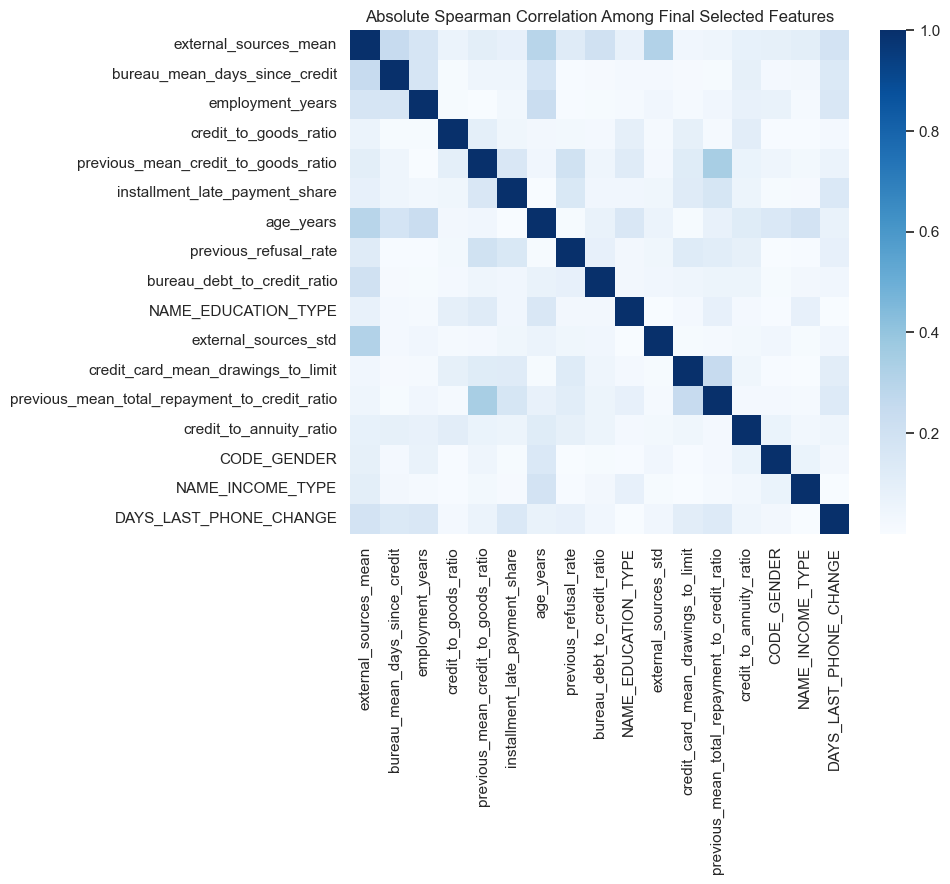

In [214]:
# Correlation matrix among gfinal selected features
selected_corr = X_train.corr(method="spearman").abs()

plt.figure(figsize=(10, 9))
sns.heatmap(selected_corr, cmap="Blues", annot=False)
plt.title("Absolute Spearman Correlation Among Final Selected Features")
plt.tight_layout()
plt.show()

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [215]:
# Train classifier
positive_count = (y_train == 1).sum()
negative_count = (y_train == 0).sum()
scale_pos_weight = negative_count / positive_count

model = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1,
)
model.fit(X_train, y_train)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Train ROC AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, y_test_proba):.4f}")

scale_pos_weight: 11.39
Train ROC AUC: 0.8212
Test ROC AUC:  0.7708


In [216]:
# Hyperparameter tuning for LightGBM using RandomizedSearchCV
base_lgbm = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1,
)
# Search space
param_distributions = {
    "n_estimators": randint(300, 1401),
    "learning_rate": loguniform(0.01, 0.08),
    "num_leaves": randint(16, 128),
    "max_depth": [-1, 3, 4, 5, 6, 8, 10, 12],
    "min_child_samples": randint(20, 201),
    "min_child_weight": loguniform(1e-3, 10),
    "subsample": uniform(0.6, 0.4),          
    "subsample_freq": randint(1, 8),
    "colsample_bytree": uniform(0.6, 0.4),   
    "reg_alpha": loguniform(1e-3, 10),
    "reg_lambda": loguniform(1e-3, 10),
    "min_split_gain": loguniform(1e-4, 0.2),
}
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_SEED,
)
random_search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
random_search.fit(X_train, y_train)

model = random_search.best_estimator_

print("Best CV ROC-AUC:", round(random_search.best_score_, 6))
print("\nBest model parameters:")
for param_name, param_value in random_search.best_params_.items():
    print(f"{param_name}: {param_value}")

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best CV ROC-AUC: 0.767721

Best model parameters:
colsample_bytree: 0.6066351315711425
learning_rate: 0.029004548764296652
max_depth: 4
min_child_samples: 167
min_child_weight: 0.38079493367685613
min_split_gain: 0.0003763473066959232
n_estimators: 1228
num_leaves: 55
reg_alpha: 0.03523233163198313
reg_lambda: 5.583672722754823
subsample: 0.6550083776583973
subsample_freq: 4


In [217]:
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

In [218]:
# Best model AUC scores on train and test
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_test_proba)

print(f"Train ROC AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC AUC:  {auc:.4f}")

Train ROC AUC: 0.8010
Test ROC AUC:  0.7731


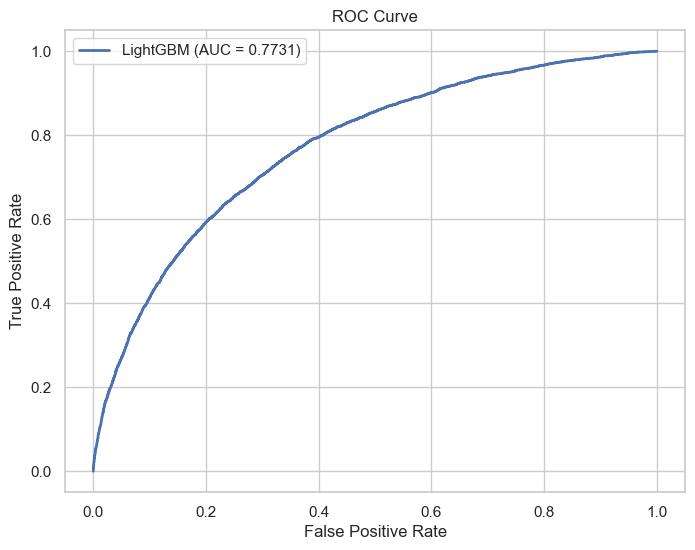

In [219]:
# ROC-AUC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"LightGBM (AUC = {auc:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [220]:
# Masterscale
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})
print(masterscale)

decision_threshold = None

   Rating  PD_lower  PD_upper
0     AAA    0.0000    0.0002
1     AA+    0.0002    0.0004
2      AA    0.0004    0.0008
3     AA-    0.0008    0.0015
4      A+    0.0015    0.0025
5       A    0.0025    0.0040
6      A-    0.0040    0.0060
7    BBB+    0.0060    0.0100
8     BBB    0.0100    0.0150
9    BBB-    0.0150    0.0250
10    BB+    0.0250    0.0400
11     BB    0.0400    0.0600
12    BB-    0.0600    0.1000
13     B+    0.1000    0.1500
14      B    0.1500    0.2000
15     B-    0.2000    0.3000
16    CCC    0.3000    0.4000
17     CC    0.4000    0.5000
18      C    0.5000    0.7000
19      D    0.7000    1.0000


In [221]:
# For each rating boundary, checking what fraction of clients would be classified as bad
threshold_table = masterscale.copy()
threshold_table["decision_threshold"] = threshold_table["PD_upper"]
threshold_table["predicted_bad_share"] = threshold_table["decision_threshold"].apply(lambda t: (y_test_proba >= t).mean())
threshold_table["predicted_bad_share_pct"] = 100 * threshold_table["predicted_bad_share"]

display(threshold_table[["Rating", "decision_threshold", "predicted_bad_share_pct"]])

,Rating,decision_threshold,predicted_bad_share_pct
0,AAA,0.0002,100.000000
1,AA+,0.0004,100.000000
2,AA,0.0008,100.000000
3,AA-,0.0015,100.000000
4,A+,0.0025,100.000000
5,A,0.0040,100.000000
6,A-,0.0060,100.000000
7,BBB+,0.0100,99.998374
8,BBB,0.0150,99.977237
9,BBB-,0.0250,99.874803


In [222]:
float(np.quantile(y_test_proba, 0.90))

0.7127857337181176

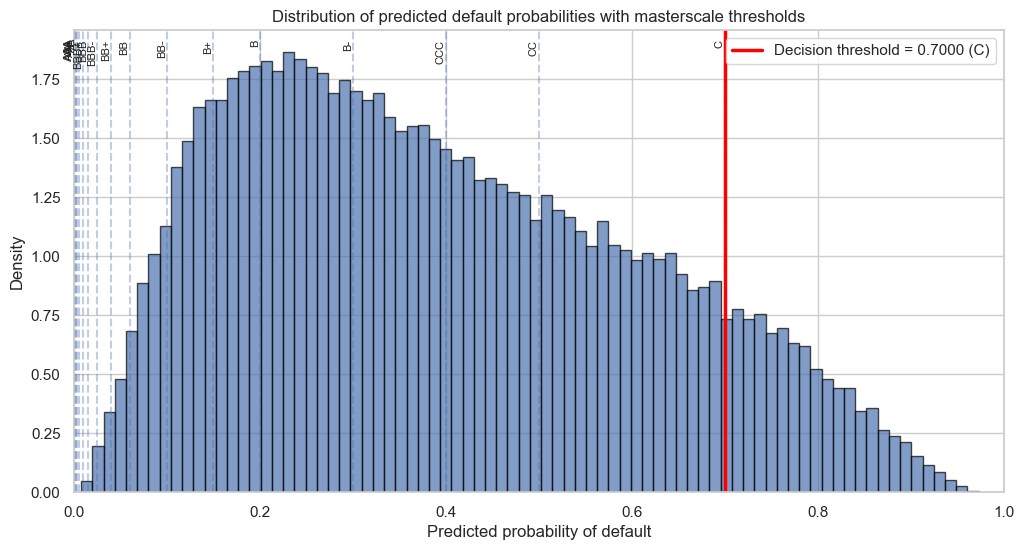

Selected rating cutoff: C
Decision threshold: 0.7000
Share classified as bad: 10.96%


In [223]:
# Choosing the strictest threshold that still classifies at least 10% as bad
valid_thresholds = threshold_table[threshold_table["predicted_bad_share"] >= 0.10].copy()

if valid_thresholds.empty:
    decision_threshold = float(np.quantile(y_test_proba, 0.90))
    selected_rating = "quantile_fallback"
else:
    chosen_row = valid_thresholds.sort_values("decision_threshold", ascending=False).iloc[0]
    decision_threshold = float(chosen_row["decision_threshold"])
    selected_rating = chosen_row["Rating"]

# Visualising probability distribution and rating thresholds
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(y_test_proba, bins=80, density=True, alpha=0.7, edgecolor="black")

x_limit = min(1.0, max(0.25, np.quantile(y_test_proba, 0.995) * 1.15))
ax.set_xlim(0, x_limit)

ymax = ax.get_ylim()[1]

for _, row in masterscale.iloc[:-1].iterrows():
    threshold = row["PD_upper"]
    if threshold <= x_limit:
        ax.axvline(threshold, linestyle="--", alpha=0.35)
        ax.text(
            threshold,
            ymax * 0.98,
            row["Rating"],
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
        )

ax.axvline(
    decision_threshold,
    color="red",
    linewidth=2.5,
    label=f"Decision threshold = {decision_threshold:.4f} ({selected_rating})"
)

ax.set_title("Distribution of predicted default probabilities with masterscale thresholds")
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Density")
ax.legend()
plt.show()

print(f"Selected rating cutoff: {selected_rating}")
print(f"Decision threshold: {decision_threshold:.4f}")
print(f"Share classified as bad: {(y_test_proba >= decision_threshold).mean() * 100:.2f}%")

,metric,value
0,ROC AUC,0.773145
1,Accuracy,0.871079
2,Balanced Accuracy,0.647314
3,Precision,0.280184
4,Recall,0.380463
5,F1-score,0.322713
6,Predicted bad share,0.109621


Classification report:

              precision    recall  f1-score   support

           0     0.9438    0.9142    0.9288     56538
           1     0.2802    0.3805    0.3227      4965

    accuracy                         0.8711     61503
   macro avg     0.6120    0.6473    0.6257     61503
weighted avg     0.8903    0.8711    0.8798     61503



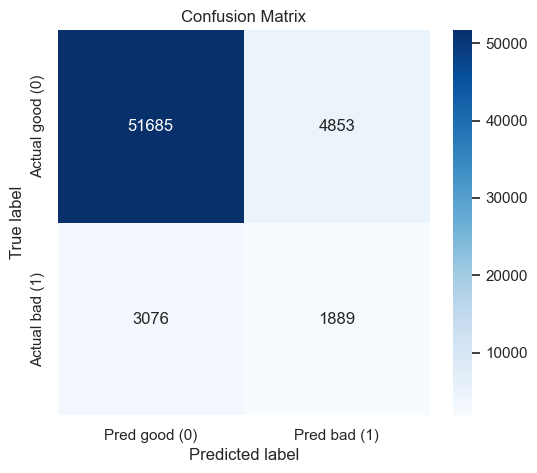

In [224]:
# Cclassification metrics
y_test_pred = (y_test_proba >= decision_threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
balanced_accuracy = (recall + specificity) / 2
predicted_bad_share = y_test_pred.mean()

metrics_df = pd.DataFrame({
    "metric": [
        "ROC AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Predicted bad share",
    ],
    "value": [
        roc_auc_score(y_test, y_test_proba),
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        predicted_bad_share,
    ],
})

display(metrics_df)

print("Classification report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred good (0)", "Pred bad (1)"],
    yticklabels=["Actual good (0)", "Actual bad (1)"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

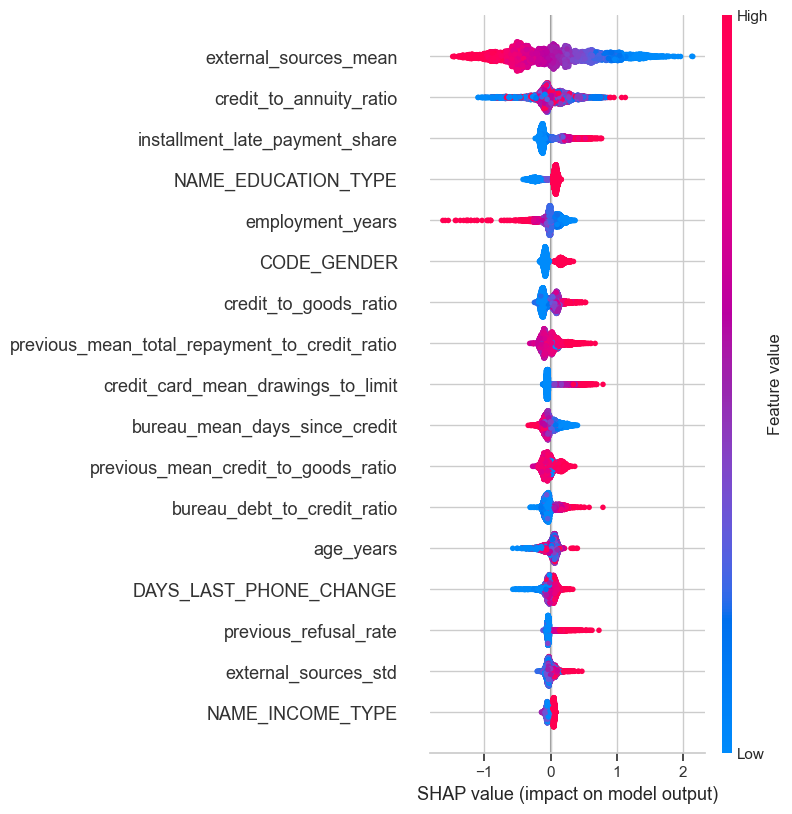

Top 10 features by mean(|SHAP|):


,mean_abs_shap
external_sources_mean,0.537789
credit_to_annuity_ratio,0.205117
installment_late_payment_share,0.152520
NAME_EDUCATION_TYPE,0.118014
employment_years,0.115236
CODE_GENDER,0.112529
credit_to_goods_ratio,0.103784
previous_mean_total_repayment_to_credit_ratio,0.101098
credit_card_mean_drawings_to_limit,0.087434
bureau_mean_days_since_credit,0.086913


In [225]:
# Plotting SHAP summary plot
shap_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=RANDOM_SEED,
)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values_array = shap_values[1]
elif hasattr(shap_values, "values"):
    shap_values_array = shap_values.values
else:
    shap_values_array = shap_values

shap.summary_plot(shap_values_array, shap_sample, max_display=20)

mean_abs_shap = (
    pd.Series(np.abs(shap_values_array).mean(axis=0), index=shap_sample.columns)
    .sort_values(ascending=False)
)

print("Top 10 features by mean(|SHAP|):")
display(mean_abs_shap.head(20).to_frame("mean_abs_shap"))

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [226]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == auc
print("Model verification passed!")

Model saved to C:\wb_allegro\models\final_model.pkl
Model verification passed!


## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [227]:
# Prep for selecting interesting examples to counterfactuals
candidates = X_test.copy()

candidates["SK_ID_CURR"] = df.loc[X_test.index, "SK_ID_CURR"].values
candidates["actual_target"] = y_test.values
candidates["predicted_pd"] = y_test_proba
candidates["predicted_label"] = (candidates["predicted_pd"] >= decision_threshold).astype(int)

# Features used for profile diversification:
candidates["external_sources_mean"] = df.loc[X_test.index, "external_sources_mean"].values
candidates["credit_to_annuity_ratio"] = df.loc[X_test.index, "credit_to_annuity_ratio"].values
candidates["employment_years"] = df.loc[X_test.index, "employment_years"].values
candidates["age_years"] = df.loc[X_test.index, "age_years"].values
candidates["installment_late_payment_share"] = df.loc[X_test.index, "installment_late_payment_share"].values
candidates["previous_refusal_rate"] = df.loc[X_test.index, "previous_refusal_rate"].values
candidates["previous_mean_total_repayment_to_credit_ratio"] = df.loc[X_test.index, "previous_mean_total_repayment_to_credit_ratio"].values
candidates["bureau_debt_to_credit_ratio"] = df.loc[X_test.index, "bureau_debt_to_credit_ratio"].values
candidates["bureau_mean_days_since_credit"] = df.loc[X_test.index, "bureau_mean_days_since_credit"].values
candidates["NAME_EDUCATION_TYPE"] = df.loc[X_test.index, "NAME_EDUCATION_TYPE"].values

# Distance to the threshold
candidates["decision_margin"] = candidates["predicted_pd"] - decision_threshold

# Confusion-matrix style categories
candidates["case_type"] = "unassigned"
candidates.loc[(candidates["actual_target"] == 1) & (candidates["predicted_label"] == 1),"case_type"] = "true_positive"
candidates.loc[(candidates["actual_target"] == 0) & (candidates["predicted_label"] == 0),"case_type"] = "true_negative"
candidates.loc[(candidates["actual_target"] == 0) & (candidates["predicted_label"] == 1),"case_type"] = "false_positive"
candidates.loc[(candidates["actual_target"] == 1) & (candidates["predicted_label"] == 0),"case_type"] = "false_negative"
display(candidates[["SK_ID_CURR", "actual_target", "predicted_pd", "predicted_label", "decision_margin", "case_type"]].head())

,SK_ID_CURR,actual_target,predicted_pd,predicted_label,decision_margin,case_type
256571,396899,0,0.309692,0,-0.390308,true_negative
191493,322041,0,0.566957,0,-0.133043,true_negative
103497,220127,0,0.644984,0,-0.055016,true_negative
130646,251531,0,0.259666,0,-0.440334,true_negative
211898,345558,0,0.641465,0,-0.058535,true_negative


In [228]:
# Choosed variables for diversity selection
diversity_features = [
    "external_sources_mean",
    "credit_to_annuity_ratio",
    "employment_years",
    "age_years",
    "installment_late_payment_share",
    "previous_refusal_rate",
    "previous_mean_total_repayment_to_credit_ratio",
    "bureau_debt_to_credit_ratio",
    "bureau_mean_days_since_credit",
    "NAME_EDUCATION_TYPE"]

In [229]:
# Function to select n cases that are both relevant (according to priority_col) and diverse in terms of the selected profile feature
def pick_diverse_cases(frame: pd.DataFrame,
    n: int,
    diversity_cols: list[str],
    priority_col: str,
    ascending: bool = True,
    pool_size: int | None = None,
    random_state: int = RANDOM_SEED) -> pd.DataFrame:

    working = frame.copy()
    working = working.sort_values(priority_col, ascending=ascending).copy()
    if pool_size is not None:
        working = working.head(pool_size).copy()

    profile_data = working[diversity_cols].copy()

    scaler = StandardScaler()
    profile_scaled = scaler.fit_transform(profile_data)

    n_clusters = min(n, len(working))

    kmeans = KMeans(n_clusters=n_clusters,random_state=random_state,n_init=20)
    working["_cluster"] = kmeans.fit_predict(profile_scaled)

    # From each cluster choosing the case with the highest value of priotity col
    selected = (working.sort_values(priority_col, ascending=ascending).groupby("_cluster", group_keys=False).head(1).copy())

    # Final ordering
    selected = (selected.sort_values(priority_col, ascending=ascending).head(n).drop(columns=["_cluster"], errors="ignore").copy())

    return selected

In [230]:
## Selecting interesting examples based on:
selected_groups= []
# 1) Near the decision threshold (sliglty above the decision threshold):
near_boundary = candidates[candidates["predicted_label"] == 1].copy()
near_boundary_cases = pick_diverse_cases(
    frame=near_boundary,
    n=4,
    diversity_cols=diversity_features,
    priority_col="decision_margin",
    ascending=True,      
    pool_size=500,        # only among the 500 closest rejected cases
    random_state=RANDOM_SEED
)
near_boundary_cases["selection_group"] = "near_boundary"
selected_groups.append(near_boundary_cases)

# 2) Correclty clasified defaults with diversed profiles
true_positive_cases = candidates[candidates["case_type"] == "true_positive"].copy()

correct_default_cases = pick_diverse_cases(
    frame=true_positive_cases,
    n=4,
    diversity_cols=diversity_features,
    priority_col="predicted_pd",
    ascending=True,  
    pool_size=500,
    random_state=RANDOM_SEED,
)
correct_default_cases["selection_group"] = "correct_default"
selected_groups.append(correct_default_cases)

# 3) Misclassified examples with diveresd profiles
false_positive_cases = candidates[candidates["case_type"] == "false_positive"].copy()

misclassified_cases_close = pick_diverse_cases(
    frame=false_positive_cases,
    n=3,
    diversity_cols=diversity_features,
    priority_col="decision_margin",
    ascending=True,      # focus on borderline wrong rejections
    pool_size=500,
    random_state=RANDOM_SEED
)
misclassified_cases_far = pick_diverse_cases(
    frame=false_positive_cases,
    n=3,
    diversity_cols=diversity_features,
    priority_col="decision_margin",
    ascending=False,      # focus on the "biggest" wrong rejections
    pool_size=500,
    random_state=RANDOM_SEED
)
misclassified_cases_close["selection_group"] = "misclassified_default_close"
misclassified_cases_far["selection_group"] = "misclassified_default_far"
selected_groups.append(misclassified_cases_close)
selected_groups.append(misclassified_cases_far)

# 4) High confidence edge cases with diversed profiles
high_confidence_bad_cases = candidates[candidates["predicted_label"] == 1].copy()
high_confidence_bad_cases = pick_diverse_cases(
    frame=high_confidence_bad_cases,
    n=2,
    diversity_cols=diversity_features,
    priority_col="predicted_pd",
    ascending=False,     # highest PD first
    pool_size=500,        
    random_state=RANDOM_SEED
)
high_confidence_bad_cases["selection_group"] = "high_confidence_bad"
selected_groups.append(high_confidence_bad_cases)

In [231]:
app_train["NAME_EDUCATION_TYPE"].unique()

array(['Secondary / secondary special', 'Higher education',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

In [232]:
# Selected examples for counterfactuals explanations:
interesting_examples = pd.concat(selected_groups, axis=0)
# Droppin dupplicates (same records given by different groups)
interesting_examples = (interesting_examples.drop_duplicates(subset=["SK_ID_CURR"]).reset_index(drop=True))

print(f"Number of selected candidates: {len(interesting_examples)}")
display(interesting_examples[["SK_ID_CURR","actual_target","predicted_label","predicted_pd","decision_margin","case_type",
    "external_sources_mean","credit_to_annuity_ratio","employment_years","age_years","installment_late_payment_share","previous_refusal_rate",
    "previous_mean_total_repayment_to_credit_ratio", "bureau_debt_to_credit_ratio","bureau_mean_days_since_credit","NAME_EDUCATION_TYPE"]])

Number of selected candidates: 12


,SK_ID_CURR,actual_target,predicted_label,predicted_pd,decision_margin,case_type,external_sources_mean,credit_to_annuity_ratio,employment_years,age_years,installment_late_payment_share,previous_refusal_rate,previous_mean_total_repayment_to_credit_ratio,bureau_debt_to_credit_ratio,bureau_mean_days_since_credit,NAME_EDUCATION_TYPE
0,331469,1,1,0.700013,0.000013,true_positive,0.122278,34.733014,1.193703,26.162902,0.000000,0.000000,0.000000,0.547500,250.500000,1
1,324608,0,1,0.700066,0.000066,false_positive,0.261192,16.217702,4.265572,22.332649,0.000000,0.000000,1.381503,0.559730,269.000000,4
2,449034,1,1,0.700157,0.000157,true_positive,0.327987,20.789045,0.364134,43.088296,0.000000,0.000000,1.448941,0.377361,1449.888889,4
3,360385,1,1,0.700195,0.000195,true_positive,0.543017,20.426487,1.119781,45.171800,0.000000,1.000000,1.772641,0.000000,2257.000000,4
4,346094,1,1,0.700193,0.000193,true_positive,0.255375,22.535877,4.511978,61.990418,0.000000,0.000000,0.000000,0.000000,0.000000,4
5,248647,0,1,0.700200,0.000200,false_positive,0.329001,20.000000,7.137577,42.154689,0.000000,0.000000,1.162978,0.571480,556.666667,4
6,237950,0,1,0.700308,0.000308,false_positive,0.307198,18.336428,2.332649,25.921971,0.175000,0.466667,1.170319,0.000000,470.000000,1
7,455614,0,1,0.957780,0.257780,false_positive,0.137854,21.342731,4.010951,39.548255,0.214286,0.000000,0.673119,0.999725,63.000000,4
8,365865,0,1,0.955298,0.255298,false_positive,0.142284,20.420039,11.553730,44.536619,0.111111,0.285714,1.084858,0.768516,287.000000,4
9,341274,0,1,0.930025,0.230025,false_positive,0.129707,20.469382,3.186858,31.203285,0.400000,0.000000,1.200690,0.698464,537.250000,1


### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [233]:
## Implementing DiCE counterfactual generation
# Displaying selected features and their data types
feature_types_df = pd.DataFrame({
    "feature": selected_feature_names,
    "dtype": [str(X_train[col].dtype) for col in selected_feature_names]
})
display(feature_types_df)

,feature,dtype
0,external_sources_mean,float64
1,bureau_mean_days_since_credit,float64
2,employment_years,float64
3,credit_to_goods_ratio,float64
4,previous_mean_credit_to_goods_ratio,float64
5,installment_late_payment_share,float64
6,age_years,float64
7,previous_refusal_rate,float64
8,bureau_debt_to_credit_ratio,float64
9,NAME_EDUCATION_TYPE,int8


In [234]:
## Prepare data and constraints for DiCE
# DiCE expects a training dataframe plus an outcome column
dice_train_df = X_train[selected_feature_names].copy()
dice_train_df[TARGET_COLUMN] = y_train.values

# We keep all features numeric in the DiCE data interface, because the model itself was trained on numeric/encoded inputs.
dice_continuous_features = selected_feature_names.copy()

# Featueres that cannot be change by client
immutable_features = [
    "age_years",  
    # "employment_years",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "bureau_mean_days_since_credit",  # can't fastforward in time
    "external_sources_mean", # hard for interpetation 
    "external_sources_std",   # hard for interpetation
    "previous_mean_credit_to_goods_ratio",   # can't change previous applications,
    # "previous_refusal_rate",     # can't change previous applications, but we keep it as it carries additional information
     "previous_mean_total_repayment_to_credit_ratio",  # can't change previous applications, but we keep it as it carries additional information 
    # "installment_late_payment_share",  # can't change previous applications, but we keep it as it carries additional information
    "credit_card_mean_drawings_to_limit",  # can't change previous applications
    "bureau_debt_to_credit_ratio", # can't change previous applications
    "DAYS_LAST_PHONE_CHANGE"  # just sounds stupid to say to a client
]
# Features allowed to change in counterfactual search
features_to_vary = [col for col in selected_feature_names if col not in immutable_features]

# Using observed ranges (inside 0.05 - 0.95 quantiles) to keep CFs inside realistic values seen in the data
reference_feature_frame = X_train[selected_feature_names].copy()

permitted_range = {}
for col in features_to_vary:
    lower = float(X_train[col].quantile(0.05))
    upper = float(X_train[col].quantile(0.95))
    if np.isfinite(lower) and np.isfinite(upper) and lower < upper:
        permitted_range[col] = [lower, upper]

# Dice couldnt hanfle high confidence examples in a finite time so we only take the ones close to the threshold (first 7)
dice_query_cases = interesting_examples.head(7).copy()  

print(f"Training rows for DiCE: {dice_train_df.shape[0]}")
print(f"Number of selected features fo Counterfactuals analysis: {len(features_to_vary)}")
print(f"Features allowed to vary: {features_to_vary}")
print(f"Number of query cases for DiCE: {len(dice_query_cases)}")

Training rows for DiCE: 246008
Number of selected features fo Counterfactuals analysis: 5
Features allowed to vary: ['employment_years', 'credit_to_goods_ratio', 'installment_late_payment_share', 'previous_refusal_rate', 'credit_to_annuity_ratio']
Number of query cases for DiCE: 7


In [235]:
# Wrapper of final model for dice
class ThresholdedLightGBMWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model, threshold, feature_names=None):
        self.base_model = base_model
        self.threshold = threshold
        self.feature_names = feature_names
        self.classes_ = np.array([0, 1])
    def fit(self, X, y=None):
        return self
    def _prepare_input(self, X):
        if isinstance(X, pd.DataFrame):
            if self.feature_names is not None:
                return X[self.feature_names]
            return X
        if self.feature_names is not None:
            return pd.DataFrame(X, columns=self.feature_names)
        return X
    def predict_proba(self, X):
        X_prepared = self._prepare_input(X)
        return self.base_model.predict_proba(X_prepared)
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

In [236]:
# Build DiCE interfaces
# Wrap the final tuned model with the notebook's decision threshold
dice_model_wrapped = ThresholdedLightGBMWrapper(
    base_model=model,
    threshold=decision_threshold,
    feature_names=selected_feature_names,
)
# Data interface
dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=dice_continuous_features,
    outcome_name=TARGET_COLUMN,
)
# Model interface
dice_model = dice_ml.Model(
    model=dice_model_wrapped,
    backend="sklearn",
)
# DiCE explainer
dice_exp = dice_ml.Dice(
    data_interface=dice_data,
    model_interface=dice_model,
    method="genetic",
)
print("DiCE objects created successfully.")
print(f"Method: genetic")
print(f"Operational threshold used by wrapper: {decision_threshold:.4f}")

DiCE objects created successfully.
Method: genetic
Operational threshold used by wrapper: 0.7000


In [237]:
# Generate one best DiCE counterfactual per case
# Hard restriction: at most 5 changed features

max_changed_features = 5

# Make sure query cases passed to DiCE are numeric
dice_query_cases = dice_query_cases.copy()
dice_query_cases[selected_feature_names] = dice_query_cases[selected_feature_names].apply(
    pd.to_numeric, errors="coerce"
)
# Use percentile-based feature spans instead of raw min/max
feature_ranges = {}
for col in features_to_vary:
    lower = float(X_train[col].quantile(0.01))
    upper = float(X_train[col].quantile(0.99))
    feature_ranges[col] = (upper - lower) if np.isfinite(lower) and np.isfinite(upper) and upper > lower else 1.0

def total_normalized_change(original_row, cf_row, feature_list, feature_ranges, tol=1e-8):
    total_change = 0.0
    changed_count = 0
    for col in feature_list:
        a = original_row[col]
        b = cf_row[col]
        if pd.isna(a) and pd.isna(b):
            continue
        if pd.api.types.is_number(a) and pd.api.types.is_number(b):
            diff = abs(float(b) - float(a))
            if diff > tol:
                total_change += diff / feature_ranges.get(col, 1.0)
                changed_count += 1
        else:
            if a != b:
                total_change += 1.0
                changed_count += 1
    return total_change, changed_count

final_rows = []
dice_log = []
for row_idx, row in dice_query_cases.iterrows():
    # Build the query instance directly from the dataframe to preserve numeric dtypes
    query_instance = dice_query_cases.loc[[row_idx], selected_feature_names].copy()
    query_instance = query_instance.apply(pd.to_numeric, errors="coerce")
    original_row = query_instance.iloc[0]
    try:
        # Ask DiCE for several candidates so that some survive the hard filter
        cf = dice_exp.generate_counterfactuals(
            query_instances=query_instance,
            total_CFs=max(8, N_COUNTERFACTUAL_EXAMPLES),
            desired_class=0,
            features_to_vary=features_to_vary,
            permitted_range=permitted_range,
            proximity_weight=5.0,
            sparsity_weight=4.0,
            diversity_weight=0.0,
            verbose=False,
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        if cf_df is None or cf_df.empty:
            dice_log.append({
                "SK_ID_CURR": row["SK_ID_CURR"],
                "selection_group": row.get("selection_group", "unknown"),
                "status": "no_counterfactual_found",
            })
            continue
        # Keep only model features and force numeric types
        cf_df = cf_df[selected_feature_names].copy()
        cf_df = cf_df.apply(pd.to_numeric, errors="coerce")

        # Score candidate counterfactuals with the original LightGBM model
        cf_predicted_pd = model.predict_proba(cf_df[selected_feature_names])[:, 1]

        # Keep only counterfactuals that truly cross below the operational threshold
        valid_mask = cf_predicted_pd < decision_threshold
        cf_df = cf_df.loc[valid_mask].copy()
        cf_predicted_pd = cf_predicted_pd[valid_mask]

        if cf_df.empty:
            dice_log.append({
                "SK_ID_CURR": row["SK_ID_CURR"],
                "selection_group": row.get("selection_group", "unknown"),
                "status": "generated_but_not_valid_under_threshold",
            })
            continue
        threshold_gaps = []
        total_changes = []
        changed_counts = []

        for _, cf_row in cf_df.iterrows():
            gap = decision_threshold - float(
                model.predict_proba(
                    cf_row[selected_feature_names].to_frame().T.apply(pd.to_numeric, errors="coerce")
                )[:, 1][0]
            )
            total_change, changed_count = total_normalized_change(
                original_row=original_row,
                cf_row=cf_row,
                feature_list=features_to_vary,
                feature_ranges=feature_ranges,
            )
            threshold_gaps.append(gap)
            total_changes.append(total_change)
            changed_counts.append(changed_count)

        cf_df = cf_df.copy()
        cf_df["cf_predicted_pd"] = cf_predicted_pd
        cf_df["threshold_gap"] = threshold_gaps
        cf_df["total_normalized_change"] = total_changes
        cf_df["n_changed_features"] = changed_counts

        # Hard restriction: at most 5 changed features
        cf_df = cf_df[cf_df["n_changed_features"] <= max_changed_features].copy()

        if cf_df.empty:
            dice_log.append({
                "SK_ID_CURR": row["SK_ID_CURR"],
                "selection_group": row.get("selection_group", "unknown"),
                "status": "no_valid_cf_with_at_most_5_changed_features",
            })
            continue

        # Best counterfactual = just below threshold + smallest total change
        cf_df = cf_df.sort_values(
            ["threshold_gap", "total_normalized_change", "n_changed_features"],
            ascending=[True, True, True]
        ).reset_index(drop=True)

        best_cf = cf_df.iloc[0]

        result_row = {
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "case_type": row.get("case_type", "unknown"),
            "original_pd": row["predicted_pd"],
            "counterfactual_pd": best_cf["cf_predicted_pd"],
            "threshold_gap": best_cf["threshold_gap"],
            "total_normalized_change": best_cf["total_normalized_change"],
            "n_changed_features": int(best_cf["n_changed_features"]),
        }

        # For each mutable feature show original value, CF value, and difference
        for col in features_to_vary:
            original_value = original_row[col]
            cf_value = best_cf[col]

            result_row[f"{col}_original"] = original_value
            result_row[f"{col}_cf"] = cf_value

            if pd.api.types.is_number(original_value) and pd.api.types.is_number(cf_value):
                result_row[f"{col}_diff"] = float(cf_value) - float(original_value)
            else:
                result_row[f"{col}_diff"] = np.nan

        final_rows.append(result_row)

        dice_log.append({
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "status": "ok",
            "counterfactual_pd": float(best_cf["cf_predicted_pd"]),
            "threshold_gap": float(best_cf["threshold_gap"]),
            "total_normalized_change": float(best_cf["total_normalized_change"]),
            "n_changed_features": int(best_cf["n_changed_features"]),
        })
    except Exception as e:
        dice_log.append({
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "status": f"error: {str(e)}",
        })
final_dice_table = pd.DataFrame(final_rows)
dice_log_df = pd.DataFrame(dice_log)

print("DiCE generation log:")
display(dice_log_df)
print("Final compact DiCE table:")
display(final_dice_table)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:22<00:00, 22.24s/it]

DiCE generation log:


,SK_ID_CURR,selection_group,status,counterfactual_pd,threshold_gap,total_normalized_change,n_changed_features
0,331469,near_boundary,error: No counterfactuals found for any of the...,NaN,NaN,NaN,NaN
1,324608,near_boundary,error: No counterfactuals found for any of the...,NaN,NaN,NaN,NaN
2,449034,near_boundary,ok,0.500927,0.199073,0.415485,3.0
3,360385,near_boundary,ok,0.456111,0.243889,2.228408,4.0
4,346094,correct_default,ok,0.491469,0.208531,0.753352,3.0
5,248647,misclassified_default_close,error: No counterfactuals found for any of the...,NaN,NaN,NaN,NaN
6,237950,misclassified_default_close,ok,0.512896,0.187104,1.292336,5.0


Final compact DiCE table:


,SK_ID_CURR,selection_group,case_type,original_pd,counterfactual_pd,threshold_gap,total_normalized_change,n_changed_features,employment_years_original,employment_years_cf,...,credit_to_goods_ratio_diff,installment_late_payment_share_original,installment_late_payment_share_cf,installment_late_payment_share_diff,previous_refusal_rate_original,previous_refusal_rate_cf,previous_refusal_rate_diff,credit_to_annuity_ratio_original,credit_to_annuity_ratio_cf,credit_to_annuity_ratio_diff
0,449034,near_boundary,true_positive,0.700157,0.500927,0.199073,0.415485,3,0.364134,1.037645,...,0.002000,0.000,0.0,0.000,0.000000,0.0,0.000000,20.789045,9.5,-11.289045
1,360385,near_boundary,true_positive,0.700195,0.456111,0.243889,2.228408,4,1.119781,1.119781,...,-0.222397,0.000,0.0,0.000,1.000000,0.0,-1.000000,20.426487,30.9,10.473513
2,346094,correct_default,true_positive,0.700193,0.491469,0.208531,0.753352,3,4.511978,16.485572,...,-0.058403,0.000,0.0,0.000,0.000000,0.0,0.000000,22.535877,16.0,-6.535877
3,237950,misclassified_default_close,false_positive,0.700308,0.512896,0.187104,1.292336,5,2.332649,0.626968,...,-0.316800,0.175,0.1,-0.075,0.466667,0.3,-0.166667,18.336428,23.7,5.363572


In [238]:
# Save the final counterfactualst from DiCE
output_path = MODELS_DIR / "dice_counterfactuals_table.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
final_dice_table.to_csv(output_path, index=False)

print(f"Saved final DiCE table to: {output_path}")

Saved final DiCE table to: C:\wb_allegro\models\dice_counterfactuals_table.csv


### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [258]:
# Data preparation for Partial Dependence plots

# Features used by the final model
pd_feature_names = selected_feature_names.copy()

# Training data in the format expected by Alibi PD
X_pd = X_train[pd_feature_names].copy()
X_pd = X_pd.iloc[0:30000]

# Black-box prediction function for Alibi
# It receives a numpy array and returns class probabilities
predict_fn_pd = lambda x: model.predict_proba(
    pd.DataFrame(x, columns=pd_feature_names)
)

# Names of model outputs (class 0 / class 1)
pd_target_names = ["good", "bad"]

# Categorical features already ordinal-encoded in the project
known_categorical_features = [
    col for col in ["CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE"]
    if col in pd_feature_names
]

# Mapping required by Alibi for categorical features
categorical_names_pd = {}

for col in known_categorical_features:
    feature_idx = pd_feature_names.index(col)
    
    values = sorted(pd.Series(X_pd[col]).dropna().astype(int).unique())
    max_val = max(values)

    labels = [f"missing_{i}" for i in range(max_val + 1)]
    for v in values:
        labels[v] = str(v)

    categorical_names_pd[feature_idx] = labels

print("Number of features:", len(pd_feature_names))
print("Categorical features passed to Alibi:", known_categorical_features)

Number of features: 17
Categorical features passed to Alibi: ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']


In [259]:
# Initialize the Alibi PartialDependence explainer

pd_explainer = PartialDependence(
    predictor=predict_fn_pd,
    feature_names=pd_feature_names,
    target_names=pd_target_names,
    categorical_names=categorical_names_pd
)

print("PartialDependence explainer initialized successfully.")

PartialDependence explainer initialized successfully.


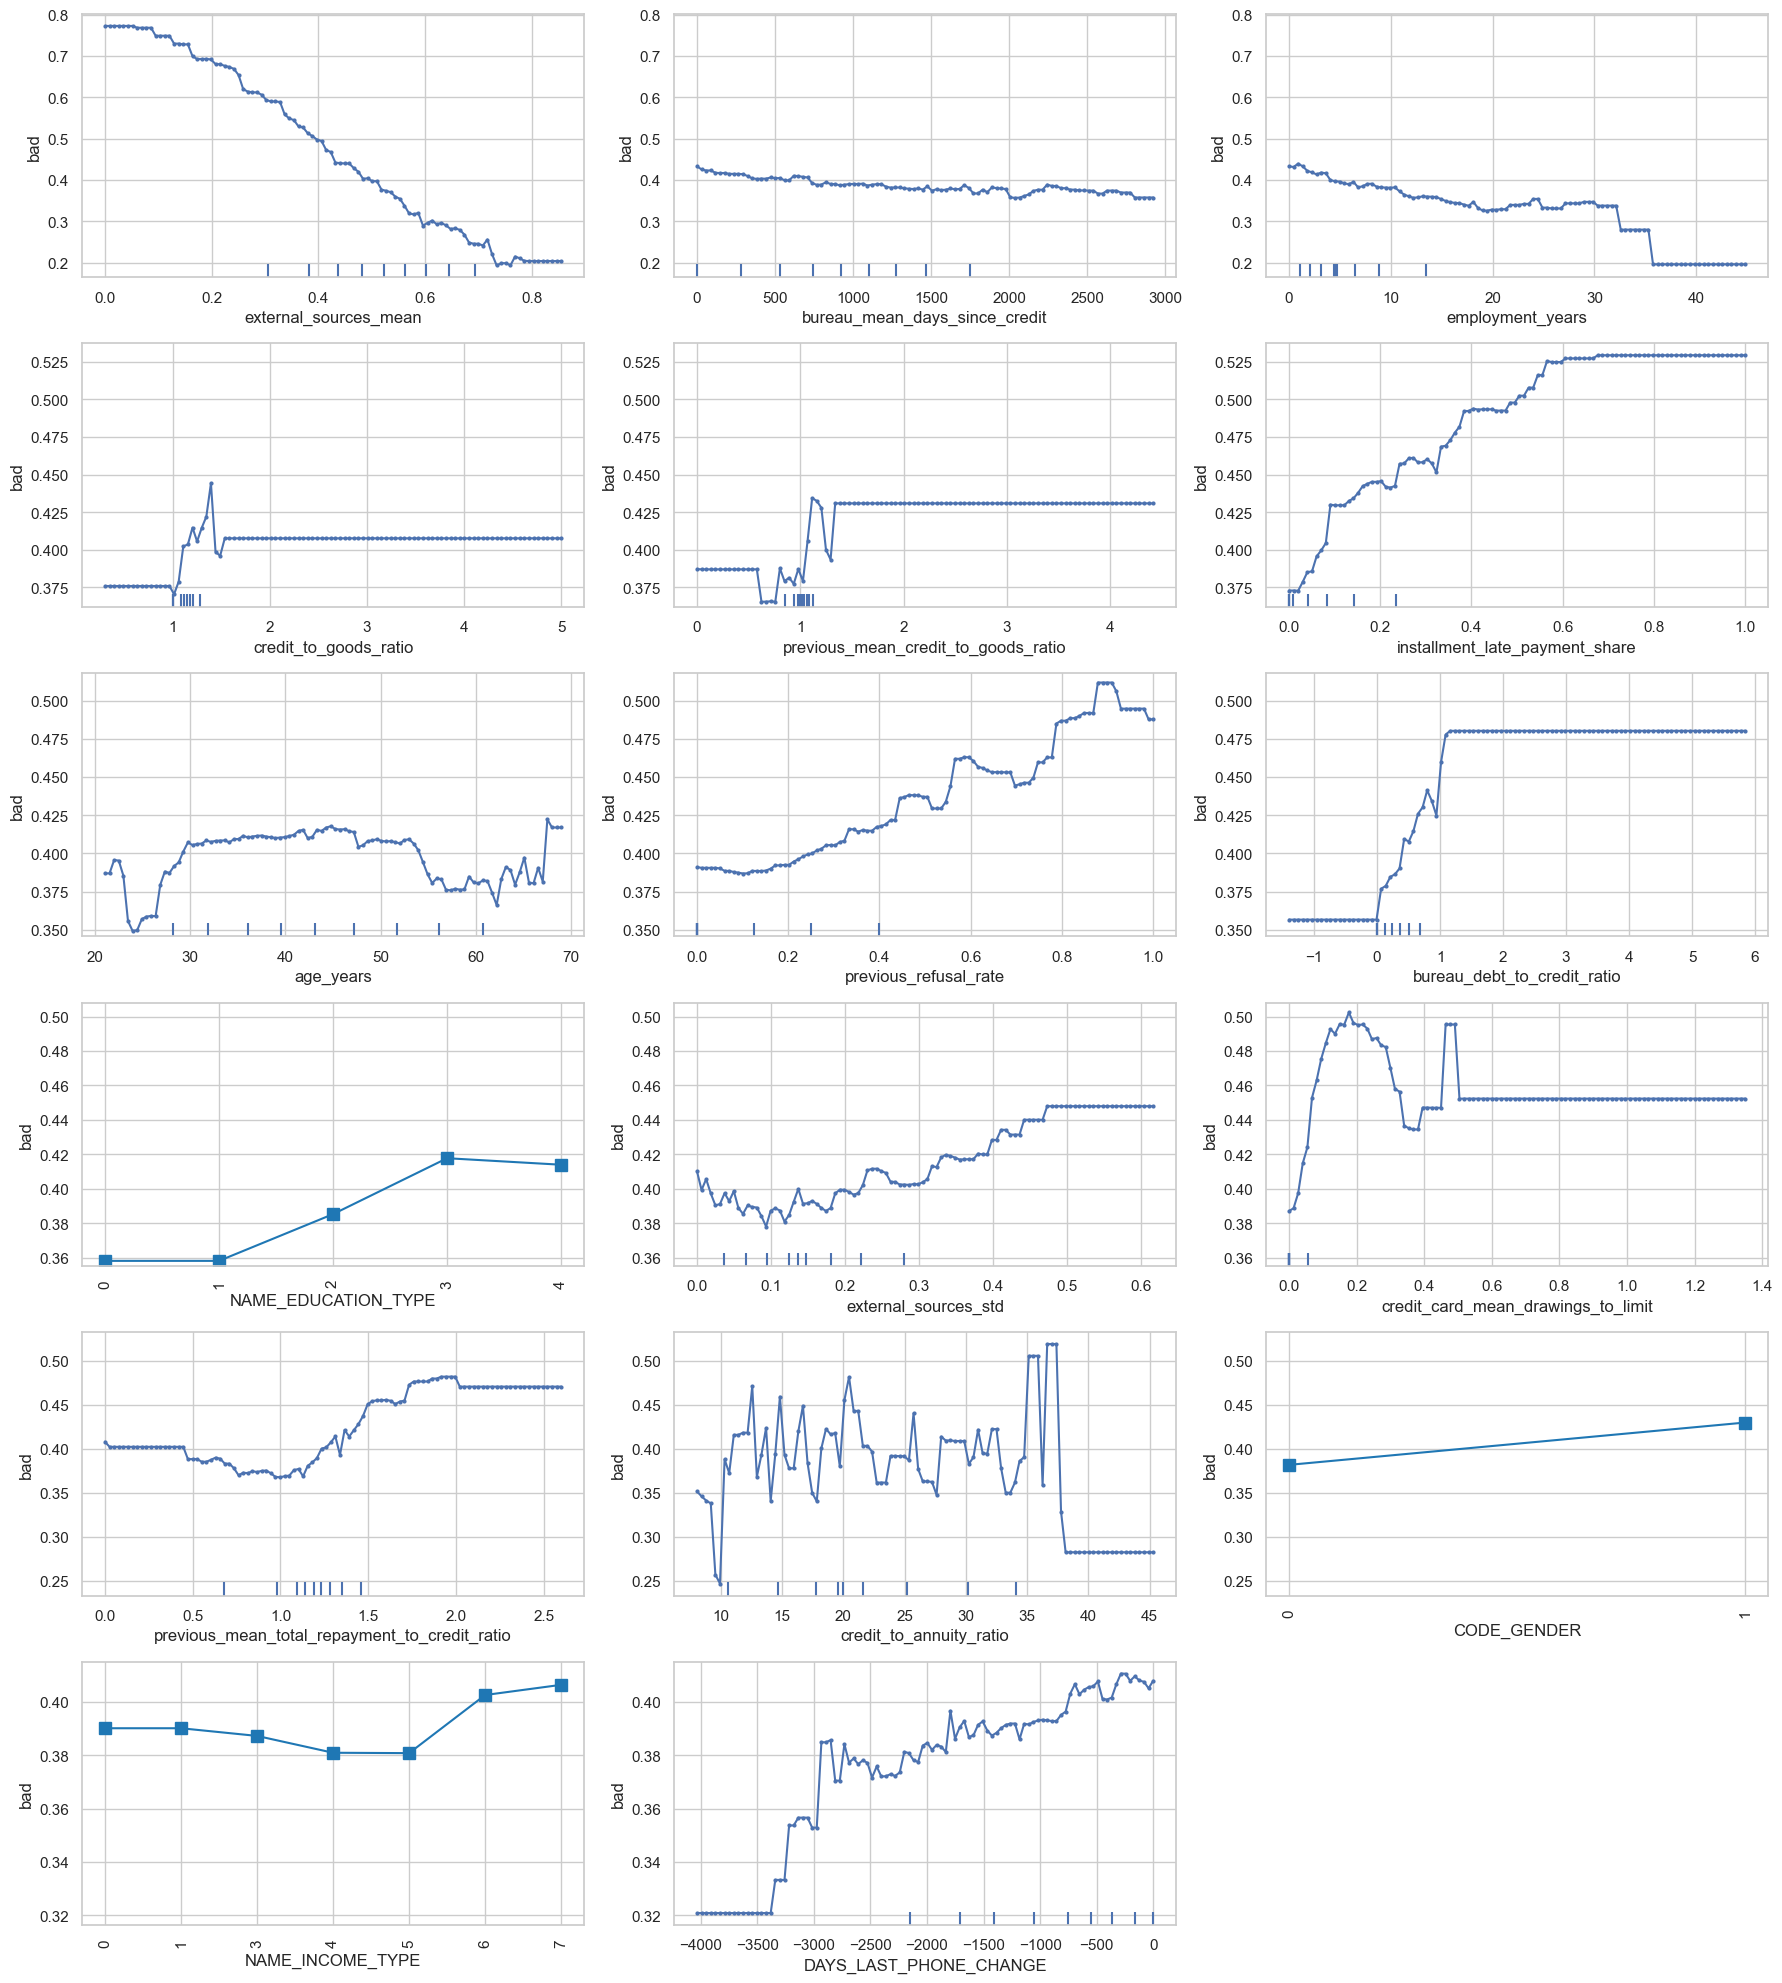

In [260]:
# Generate a separate PD plot for each feature

feature_indices = list(range(len(pd_feature_names)))

exp_pd_all = pd_explainer.explain(
    X=X_pd.to_numpy(),
    features=feature_indices,
    kind="average"
)
plot_pd(
    exp=exp_pd_all,
    features=list(range(len(feature_indices))),
    target=1,          # class 1 = bad
    n_cols=3,          # number of columns in the grid
    sharey="row",
    fig_kw={"figheight": 20, "figwidth": 18}
)
plt.tight_layout()
plt.show()

In [242]:
# Data preparation for Alibi CounterfactualProto
# Alibi changes only mutable features, but LightGBM receives all model features.

from alibi.explainers import CounterfactualProto
import tensorflow as tf
import numpy as np
import pandas as pd

# CounterfactualProto in Alibi needs TF graph mode
tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()
tf.keras.backend.clear_session()

# Full set of features used by the LightGBM model
alibi_model_feature_names = selected_feature_names.copy()

# Only these features are allowed to change
alibi_feature_names = features_to_vary.copy()

# Features that will stay fixed during Alibi counterfactual generation
alibi_fixed_feature_names = [
    col for col in alibi_model_feature_names
    if col not in alibi_feature_names
]

# Safety checks
missing_mutable = [col for col in alibi_feature_names if col not in alibi_model_feature_names]
if missing_mutable:
    raise ValueError(f"These features_to_vary are not in selected_feature_names: {missing_mutable}")

missing_in_train = [col for col in alibi_model_feature_names if col not in X_train.columns]
if missing_in_train:
    raise ValueError(f"These model features are missing in X_train: {missing_in_train}")

# We explain only rejected / bad cases
alibi_query_cases = interesting_examples[
    interesting_examples["predicted_label"] == 1
].copy()

# Training matrix used by Alibi - only mutable features
alibi_X_train = (
    X_train[alibi_feature_names]
    .copy()
    .astype(np.float32)
    .to_numpy()
)

# Feature-wise ranges from training data - only mutable features
alibi_feature_min = alibi_X_train.min(axis=0).reshape(1, -1).astype(np.float32)
alibi_feature_max = alibi_X_train.max(axis=0).reshape(1, -1).astype(np.float32)
alibi_feature_range = (alibi_feature_min, alibi_feature_max)

# Ordinally encoded categorical variables present among mutable features
alibi_categorical_feature_names = [
    col for col in ["CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE"]
    if col in alibi_feature_names
]

cat_vars = {
    alibi_feature_names.index(col): int(X_train[col].nunique())
    for col in alibi_categorical_feature_names
}

# This row is used as the fixed base for non-mutable features.
# It will be updated before every cfproto.explain() call.
alibi_current_base_full_row = (
    alibi_query_cases.iloc[0][alibi_model_feature_names]
    .copy()
    .astype(np.float32)
)

print("Number of LightGBM model features:", len(alibi_model_feature_names))
print("Number of mutable Alibi features:", len(alibi_feature_names))
print("Number of fixed features:", len(alibi_fixed_feature_names))
print("Mutable features:", alibi_feature_names)
print("Fixed features:", alibi_fixed_feature_names)
print("Number of rejected cases to explain:", len(alibi_query_cases))
print("Categorical variables passed to Alibi:", cat_vars)
print("Alibi training matrix shape:", alibi_X_train.shape)
print("Eager execution enabled:", tf.executing_eagerly())

Number of LightGBM model features: 17
Number of mutable Alibi features: 5
Number of fixed features: 12
Mutable features: ['employment_years', 'credit_to_goods_ratio', 'installment_late_payment_share', 'previous_refusal_rate', 'credit_to_annuity_ratio']
Fixed features: ['external_sources_mean', 'bureau_mean_days_since_credit', 'previous_mean_credit_to_goods_ratio', 'age_years', 'bureau_debt_to_credit_ratio', 'NAME_EDUCATION_TYPE', 'external_sources_std', 'credit_card_mean_drawings_to_limit', 'previous_mean_total_repayment_to_credit_ratio', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'DAYS_LAST_PHONE_CHANGE']
Number of rejected cases to explain: 12
Categorical variables passed to Alibi: {}
Alibi training matrix shape: (246008, 5)
Eager execution enabled: False


In [243]:
# Prediction function and CounterfactualProto initialization

ALIBI_DECISION_STEEPNESS = 10.0


def build_full_model_input_from_alibi(x_mutable: np.ndarray) -> pd.DataFrame:
    """
    Alibi changes only mutable features.
    This function reconstructs the full LightGBM input:
    - fixed features are copied from the currently explained observation,
    - mutable features are replaced with Alibi values.
    """
    x_mutable = np.asarray(x_mutable, dtype=np.float32)

    if x_mutable.ndim == 1:
        x_mutable = x_mutable.reshape(1, -1)

    if x_mutable.shape[1] != len(alibi_feature_names):
        raise ValueError(
            f"Alibi passed {x_mutable.shape[1]} features, "
            f"but expected {len(alibi_feature_names)} mutable features."
        )

    n_rows = x_mutable.shape[0]

    base_values = np.repeat(
        alibi_current_base_full_row[alibi_model_feature_names]
        .to_numpy(dtype=np.float32)
        .reshape(1, -1),
        repeats=n_rows,
        axis=0,
    )

    full_df = pd.DataFrame(
        base_values,
        columns=alibi_model_feature_names,
    )

    full_df.loc[:, alibi_feature_names] = x_mutable

    return full_df[alibi_model_feature_names].astype(np.float32)


def alibi_predict_fn(x: np.ndarray) -> np.ndarray:
    """
    Alibi receives only mutable features.
    LightGBM receives all model features.
    """
    x_full_df = build_full_model_input_from_alibi(x)

    raw_pd_bad = model.predict_proba(x_full_df[alibi_model_feature_names])[:, 1]

    p_bad_operational = 1.0 / (
        1.0 + np.exp(-ALIBI_DECISION_STEEPNESS * (raw_pd_bad - decision_threshold))
    )
    p_good_operational = 1.0 - p_bad_operational

    return np.column_stack([p_good_operational, p_bad_operational]).astype(np.float32)


cfproto = CounterfactualProto(
    predict=alibi_predict_fn,
    shape=(1, alibi_X_train.shape[1]),
    use_kdtree=True,
    feature_range=alibi_feature_range,
    cat_vars=cat_vars,
    ohe=False,
    theta=1.0,
    beta=0.01,
    c_init=1.0,
    c_steps=5,
    max_iterations=2000,
    eps=(1e-3, 1e-3),
    update_num_grad=1,
    clip=(-1000.0, 1000.0),
)

cfproto.fit(
    alibi_X_train,
    trustscore_kwargs=None,
    d_type="abdm-mvdm",
    w=0.5,
    disc_perc=[25, 50, 75],
    standardize_cat_vars=False,
    smooth=1.0,
    center=True,
    update_feature_range=True,
)

print("CounterfactualProto initialized and fitted successfully.")

No encoder specified. Using k-d trees to represent class prototypes.


CounterfactualProto initialized and fitted successfully.


In [244]:
# Generate Alibi counterfactuals for rejected cases
# Only mutable features are changed. Fixed features stay copied from the original observation.

def changed_features_alibi(original_row, cf_row, feature_list, tol=1e-8):
    changed = []

    for col in feature_list:
        a = original_row[col]
        b = cf_row[col]

        if pd.isna(a) and pd.isna(b):
            continue

        if pd.isna(a) or pd.isna(b):
            changed.append(col)
            continue

        if isinstance(a, (int, float, np.integer, np.floating)) and isinstance(
            b, (int, float, np.integer, np.floating)
        ):
            if not np.isclose(float(a), float(b), atol=tol, rtol=0):
                changed.append(col)
        else:
            if a != b:
                changed.append(col)

    return changed


alibi_result_rows = []
alibi_log = []

for row_idx, row in alibi_query_cases.iterrows():

    # Update fixed base row for this specific observation
    alibi_current_base_full_row = (
        row[alibi_model_feature_names]
        .copy()
        .astype(np.float32)
    )

    # Alibi receives only mutable features
    x_query_df = alibi_query_cases.loc[[row_idx], alibi_feature_names].copy()
    x_query = x_query_df.astype(np.float32).to_numpy()

    # Full original row for LightGBM comparison
    original_full_df = (
        alibi_query_cases.loc[[row_idx], alibi_model_feature_names]
        .copy()
        .astype(np.float32)
    )

    try:
        explanation = cfproto.explain(
            X=x_query,
            target_class=[0],   # move from rejected/bad to accepted/good
            k=50,
            k_type="mean",
            threshold=0.0,
            verbose=False,
        )

        if explanation is None or explanation.data.get("cf") is None:
            alibi_log.append({
                "SK_ID_CURR": row["SK_ID_CURR"],
                "selection_group": row.get("selection_group", "unknown"),
                "status": "no_counterfactual_found",
            })
            continue

        cf_data = explanation.data["cf"]
        cf_x = cf_data.get("X", None)

        if cf_x is None:
            alibi_log.append({
                "SK_ID_CURR": row["SK_ID_CURR"],
                "selection_group": row.get("selection_group", "unknown"),
                "status": "no_counterfactual_found",
            })
            continue

        # Counterfactual with only mutable features
        cf_mutable_df = pd.DataFrame(cf_x, columns=alibi_feature_names)

        # Reconstruct full LightGBM input:
        # fixed features from original row + mutable features from Alibi CF
        cf_full_df = original_full_df.copy()
        cf_full_df.loc[:, alibi_feature_names] = cf_mutable_df.iloc[0][alibi_feature_names].values
        cf_full_df = cf_full_df[alibi_model_feature_names].astype(np.float32)

        # Score CF with the original LightGBM model
        cf_predicted_pd = float(model.predict_proba(cf_full_df)[:, 1][0])
        cf_predicted_label = int(cf_predicted_pd >= decision_threshold)

        # Check changed mutable features
        changed_mutable = changed_features_alibi(
            original_row=original_full_df.iloc[0],
            cf_row=cf_full_df.iloc[0],
            feature_list=alibi_feature_names,
        )

        # Check fixed features
        changed_fixed = changed_features_alibi(
            original_row=original_full_df.iloc[0],
            cf_row=cf_full_df.iloc[0],
            feature_list=alibi_fixed_feature_names,
        )

        result_row = cf_full_df.iloc[0].to_dict()

        result_row.update({
            "SK_ID_CURR": row["SK_ID_CURR"],
            "source_index": row_idx,
            "selection_group": row.get("selection_group", "unknown"),
            "case_type": row.get("case_type", "unknown"),
            "original_actual_target": row["actual_target"],
            "original_predicted_pd": row["predicted_pd"],
            "original_predicted_label": row["predicted_label"],
            "cf_predicted_pd": cf_predicted_pd,
            "cf_predicted_label": cf_predicted_label,
            "changed_features": ", ".join(changed_mutable),
            "n_changed_features": len(changed_mutable),
            "fixed_features_changed": ", ".join(changed_fixed),
            "n_fixed_features_changed": len(changed_fixed),
        })

        alibi_result_rows.append(result_row)

        alibi_log.append({
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "status": "ok",
            "original_predicted_pd": float(row["predicted_pd"]),
            "cf_predicted_pd": cf_predicted_pd,
            "cf_predicted_label": cf_predicted_label,
            "n_changed_features": len(changed_mutable),
            "changed_features": ", ".join(changed_mutable),
            "n_fixed_features_changed": len(changed_fixed),
        })

    except Exception as e:
        alibi_log.append({
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "status": f"error: {str(e)}",
        })


alibi_log_df = pd.DataFrame(alibi_log)

if len(alibi_result_rows) > 0:
    alibi_counterfactuals_df = pd.DataFrame(alibi_result_rows)
else:
    alibi_counterfactuals_df = pd.DataFrame()

print("Alibi generation log:")
display(alibi_log_df)

print(f"Total Alibi counterfactuals generated: {len(alibi_counterfactuals_df)}")

No counterfactual found!
No counterfactual found!
No counterfactual found!
No counterfactual found!
No counterfactual found!
No counterfactual found!


Alibi generation log:


,SK_ID_CURR,selection_group,status,original_predicted_pd,cf_predicted_pd,cf_predicted_label,n_changed_features,changed_features,n_fixed_features_changed
0,331469,near_boundary,ok,0.700013,0.694525,0.0,1.0,installment_late_payment_share,0.0
1,324608,near_boundary,no_counterfactual_found,NaN,NaN,NaN,NaN,NaN,NaN
2,449034,near_boundary,ok,0.700157,0.699718,0.0,1.0,installment_late_payment_share,0.0
3,360385,near_boundary,ok,0.700195,0.621282,0.0,1.0,credit_to_goods_ratio,0.0
4,346094,correct_default,ok,0.700193,0.676324,0.0,1.0,credit_to_goods_ratio,0.0
5,248647,misclassified_default_close,ok,0.700200,0.691886,0.0,1.0,installment_late_payment_share,0.0
6,237950,misclassified_default_close,ok,0.700308,0.693055,0.0,1.0,credit_to_goods_ratio,0.0
7,455614,misclassified_default_far,no_counterfactual_found,NaN,NaN,NaN,NaN,NaN,NaN
8,365865,misclassified_default_far,no_counterfactual_found,NaN,NaN,NaN,NaN,NaN,NaN
9,341274,misclassified_default_far,no_counterfactual_found,NaN,NaN,NaN,NaN,NaN,NaN


Total Alibi counterfactuals generated: 6


In [245]:
# Save the final counterfactualst from  Alibi
output_path = MODELS_DIR / "alibi_counterfactuals_table.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
alibi_counterfactuals_df.to_csv(output_path, index=False)

print(f"Saved final Alibi table to: {output_path}")

Saved final Alibi table to: C:\wb_allegro\models\alibi_counterfactuals_table.csv


In [246]:
# Display original observation + Alibi counterfactual for every explained case

from IPython.display import display, Markdown
import numpy as np
import pandas as pd

# Columns to show in each table
display_cols = [
    "version",
    "predicted_pd",
    "predicted_label",
] + alibi_feature_names

# Prepare cases with source index
alibi_query_cases_display = (
    alibi_query_cases
    .reset_index()
    .rename(columns={"index": "source_index"})
    .copy()
)

all_alibi_comparison_tables = []

for display_case_number_alibi, chosen_case_alibi in enumerate(
    alibi_query_cases_display.to_dict("records"),
    start=1
):

    sk_id = chosen_case_alibi["SK_ID_CURR"]

    display(Markdown("---"))
    display(Markdown(f"### Observation {display_case_number_alibi} — SK_ID_CURR: `{sk_id}`"))

    # Counterfactuals found for this observation
    if (
        "SK_ID_CURR" in alibi_counterfactuals_df.columns
        and not alibi_counterfactuals_df.empty
    ):
        cf_subset_alibi = alibi_counterfactuals_df[
            alibi_counterfactuals_df["SK_ID_CURR"] == sk_id
        ].copy()
    else:
        cf_subset_alibi = pd.DataFrame()

    # Original row
    original_row_df_alibi = (
        pd.DataFrame([chosen_case_alibi])[alibi_feature_names]
        .copy()
    )

    original_row_df_alibi.insert(0, "version", "ORIGINAL")
    original_row_df_alibi.insert(1, "predicted_pd", chosen_case_alibi["predicted_pd"])
    original_row_df_alibi.insert(2, "predicted_label", chosen_case_alibi["predicted_label"])

    # If counterfactual was found
    if not cf_subset_alibi.empty:

        cf_rows_df_alibi = cf_subset_alibi[alibi_feature_names].copy()

        cf_rows_df_alibi.insert(0, "version", "ALIBI_CF")
        cf_rows_df_alibi.insert(1, "predicted_pd", cf_subset_alibi["cf_predicted_pd"].values)
        cf_rows_df_alibi.insert(2, "predicted_label", cf_subset_alibi["cf_predicted_label"].values)

        alibi_comparison_table = pd.concat(
            [original_row_df_alibi, cf_rows_df_alibi],
            ignore_index=True
        )

        status = "counterfactual_found"

    # If counterfactual was not found
    else:

        no_cf_row = original_row_df_alibi.copy()
        no_cf_row.loc[:, "version"] = "NO_ALIBI_CF_FOUND"
        no_cf_row.loc[:, "predicted_pd"] = np.nan
        no_cf_row.loc[:, "predicted_label"] = np.nan

        alibi_comparison_table = pd.concat(
            [original_row_df_alibi, no_cf_row],
            ignore_index=True
        )

        status = "no_counterfactual_found"

    # Add metadata
    alibi_comparison_table.insert(0, "SK_ID_CURR", sk_id)
    alibi_comparison_table.insert(1, "observation_number", display_case_number_alibi)
    alibi_comparison_table.insert(2, "selection_group", chosen_case_alibi.get("selection_group", "unknown"))
    alibi_comparison_table.insert(3, "status", status)

    # Display one table for this observation
    display(
        alibi_comparison_table[
            [
                "SK_ID_CURR",
                "observation_number",
                "selection_group",
                "status",
            ] + display_cols
        ]
    )

    all_alibi_comparison_tables.append(alibi_comparison_table)

---

### Observation 1 — SK_ID_CURR: `331469`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,331469,1,near_boundary,counterfactual_found,ORIGINAL,0.700013,1,1.193703,1.396,0.000000,0.0,34.733014
1,331469,1,near_boundary,counterfactual_found,ALIBI_CF,0.694525,0,1.193703,1.396,0.000005,0.0,34.733013


---

### Observation 2 — SK_ID_CURR: `324608`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,324608,2,near_boundary,no_counterfactual_found,ORIGINAL,0.700066,1.0,4.265572,1.0,0.0,0.0,16.217702
1,324608,2,near_boundary,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,4.265572,1.0,0.0,0.0,16.217702


---

### Observation 3 — SK_ID_CURR: `449034`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,449034,3,near_boundary,counterfactual_found,ORIGINAL,0.700157,1,0.364134,1.198,0.000000,0.0,20.789045
1,449034,3,near_boundary,counterfactual_found,ALIBI_CF,0.699718,0,0.364134,1.198,0.000008,0.0,20.789045


---

### Observation 4 — SK_ID_CURR: `360385`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,360385,4,near_boundary,counterfactual_found,ORIGINAL,0.700195,1,1.119781,1.422397,0.0,1.0,20.426487
1,360385,4,near_boundary,counterfactual_found,ALIBI_CF,0.621282,0,1.119781,1.422433,0.0,1.0,20.426487


---

### Observation 5 — SK_ID_CURR: `346094`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,346094,5,correct_default,counterfactual_found,ORIGINAL,0.700193,1,4.511978,1.158403,0.0,0.0,22.535877
1,346094,5,correct_default,counterfactual_found,ALIBI_CF,0.676324,0,4.511978,1.158396,0.0,0.0,22.535877


---

### Observation 6 — SK_ID_CURR: `248647`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,248647,6,misclassified_default_close,counterfactual_found,ORIGINAL,0.700200,1,7.137577,1.0,0.000000,0.0,20.0
1,248647,6,misclassified_default_close,counterfactual_found,ALIBI_CF,0.691886,0,7.137577,1.0,0.000007,0.0,20.0


---

### Observation 7 — SK_ID_CURR: `237950`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,237950,7,misclassified_default_close,counterfactual_found,ORIGINAL,0.700308,1,2.332649,1.316800,0.175,0.466667,18.336428
1,237950,7,misclassified_default_close,counterfactual_found,ALIBI_CF,0.693055,0,2.332649,1.316805,0.175,0.466667,18.336428


---

### Observation 8 — SK_ID_CURR: `455614`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,455614,8,misclassified_default_far,no_counterfactual_found,ORIGINAL,0.95778,1.0,4.010951,1.2112,0.214286,0.0,21.342731
1,455614,8,misclassified_default_far,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,4.010951,1.2112,0.214286,0.0,21.342731


---

### Observation 9 — SK_ID_CURR: `365865`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,365865,9,misclassified_default_far,no_counterfactual_found,ORIGINAL,0.955298,1.0,11.55373,1.2112,0.111111,0.285714,20.420039
1,365865,9,misclassified_default_far,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,11.55373,1.2112,0.111111,0.285714,20.420039


---

### Observation 10 — SK_ID_CURR: `341274`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,341274,10,misclassified_default_far,no_counterfactual_found,ORIGINAL,0.930025,1.0,3.186858,1.422404,0.4,0.0,20.469382
1,341274,10,misclassified_default_far,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,3.186858,1.422404,0.4,0.0,20.469382


---

### Observation 11 — SK_ID_CURR: `243023`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,243023,11,high_confidence_bad,no_counterfactual_found,ORIGINAL,0.973105,1.0,3.318275,1.1056,0.28125,0.8,12.657127
1,243023,11,high_confidence_bad,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,3.318275,1.1056,0.28125,0.8,12.657127


---

### Observation 12 — SK_ID_CURR: `163956`

,SK_ID_CURR,observation_number,selection_group,status,version,predicted_pd,predicted_label,employment_years,credit_to_goods_ratio,installment_late_payment_share,previous_refusal_rate,credit_to_annuity_ratio
0,163956,12,high_confidence_bad,no_counterfactual_found,ORIGINAL,0.965402,1.0,0.77755,1.3168,0.5,0.8,14.734251
1,163956,12,high_confidence_bad,no_counterfactual_found,NO_ALIBI_CF_FOUND,NaN,NaN,0.77755,1.3168,0.5,0.8,14.734251


## 8. Evaluation & Benchmarking

In [247]:
# DALEX setup and Explainer object

import dalex as dx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# DALEX calculations can be slow on the full test set, so we use a representative sample.
DALEX_SAMPLE_SIZE = 60000

# Make sure y_test is aligned with X_test by row order
y_test_series = pd.Series(
    np.asarray(y_test),
    index=X_test.index,
    name=TARGET_COLUMN
)

dalex_eval_index = (
    X_test
    .sample(
        n=min(DALEX_SAMPLE_SIZE, len(X_test)),
        random_state=RANDOM_SEED
    )
    .index
)

dalex_X = (
    X_test.loc[dalex_eval_index, selected_feature_names]
    .copy()
    .apply(pd.to_numeric, errors="coerce")
)

dalex_y = y_test_series.loc[dalex_eval_index].copy()


def dalex_predict_function(model_object, data):
    """
    Prediction function required by DALEX.

    DALEX passes a dataframe or numpy array.
    The function returns the predicted probability of class 1, meaning default / bad client.
    """
    if isinstance(data, pd.DataFrame):
        data_df = data.copy()
    else:
        data_df = pd.DataFrame(data, columns=selected_feature_names)

    data_df = (
        data_df[selected_feature_names]
        .copy()
        .apply(pd.to_numeric, errors="coerce")
    )

    return model_object.predict_proba(data_df)[:, 1]


dalex_explainer = dx.Explainer(
    model=model,
    data=dalex_X,
    y=dalex_y,
    predict_function=dalex_predict_function,
    label="Final LightGBM model",
    model_type="classification",
    verbose=False,
)

print("DALEX Explainer created successfully.")
print(f"DALEX data shape: {dalex_X.shape}")
print(f"Decision threshold used in the project: {decision_threshold:.4f}")

DALEX Explainer created successfully.
DALEX data shape: (60000, 17)
Decision threshold used in the project: 0.7000


DALEX model performance:


,recall,precision,f1,accuracy,auc
Final LightGBM model,0.38043,0.279356,0.322151,0.871017,0.772606


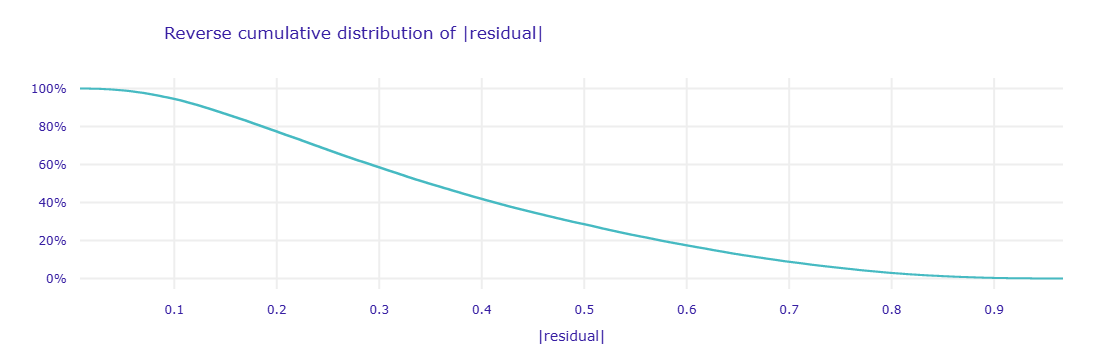

In [248]:
# DALEX model performance

dalex_model_performance = dalex_explainer.model_performance(
    model_type="classification",
    cutoff=decision_threshold,
)

print("DALEX model performance:")
display(dalex_model_performance.result)

# Plot DALEX performance diagnostics
try:
    fig = dalex_model_performance.plot(show=False)
    fig.show()
except TypeError:
    dalex_model_performance.plot()

DALEX permutation variable importance:


,variable,dropout_loss,label
0,_full_model_,0.225364,Final LightGBM model
1,NAME_INCOME_TYPE,0.226054,Final LightGBM model
2,external_sources_std,0.226926,Final LightGBM model
3,CODE_GENDER,0.227677,Final LightGBM model
4,previous_mean_credit_to_goods_ratio,0.228284,Final LightGBM model
5,bureau_mean_days_since_credit,0.228347,Final LightGBM model
6,previous_refusal_rate,0.228664,Final LightGBM model
7,bureau_debt_to_credit_ratio,0.228737,Final LightGBM model
8,DAYS_LAST_PHONE_CHANGE,0.229664,Final LightGBM model
9,previous_mean_total_repayment_to_credit_ratio,0.229767,Final LightGBM model


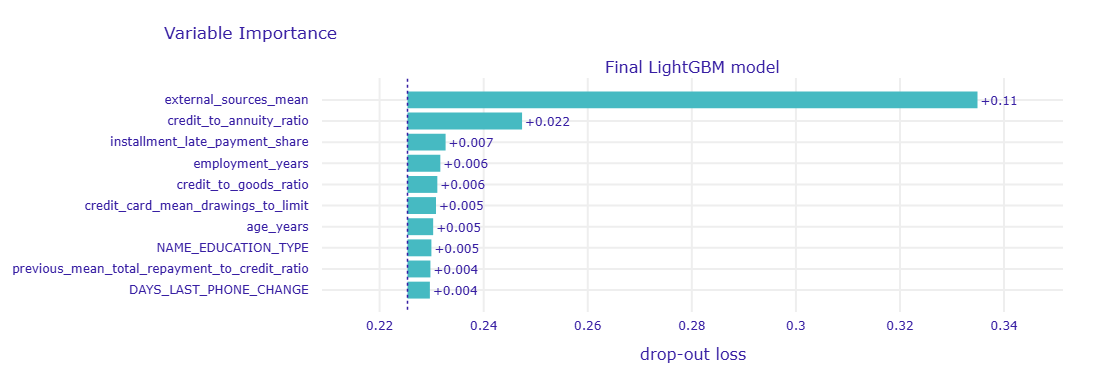

In [249]:
# DALEX permutation-based variable importance

dalex_variable_importance = dalex_explainer.model_parts(
    type="variable_importance",
    loss_function="1-auc",
    N=min(3000, len(dalex_X)),
    B=10,
    random_state=RANDOM_SEED,
)

dalex_variable_importance_table = dalex_variable_importance.result.copy()

print("DALEX permutation variable importance:")
display(dalex_variable_importance_table)

try:
    fig = dalex_variable_importance.plot(show=False)
    fig.show()
except TypeError:
    dalex_variable_importance.plot()

Variables used for DALEX PDP profiles:
['employment_years', 'credit_to_goods_ratio', 'installment_late_payment_share', 'previous_refusal_rate', 'credit_to_annuity_ratio']
DALEX Partial Dependence result preview:


,_vname_,_label_,_x_,_yhat_,_ids_
0,employment_years,Final LightGBM model,0.000000,0.424033,0
1,employment_years,Final LightGBM model,0.509149,0.422153,0
2,employment_years,Final LightGBM model,0.761123,0.426512,0
3,employment_years,Final LightGBM model,1.073238,0.422978,0
4,employment_years,Final LightGBM model,1.396304,0.419830,0
5,employment_years,Final LightGBM model,1.727584,0.416770,0
6,employment_years,Final LightGBM model,2.067077,0.411498,0
7,employment_years,Final LightGBM model,2.398357,0.411095,0
8,employment_years,Final LightGBM model,2.750810,0.404778,0
9,employment_years,Final LightGBM model,3.110198,0.409353,0


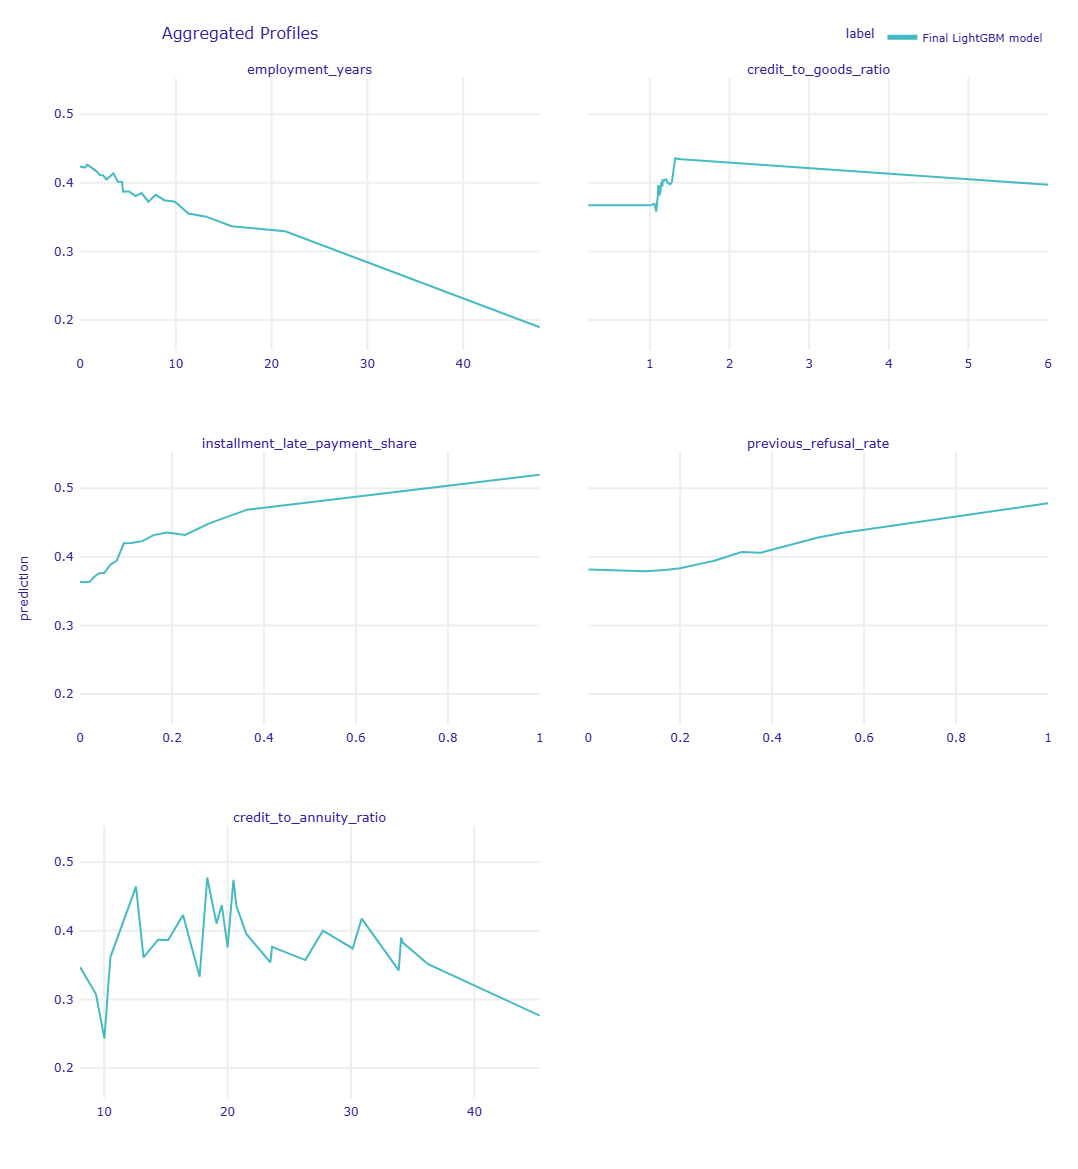

In [250]:
# DALEX Partial Dependence Profiles
# We focus on mutable features because they are the features later used in counterfactual explanations.

dalex_profile_variables = [
    col for col in features_to_vary
    if col in selected_feature_names
]

print("Variables used for DALEX PDP profiles:")
print(dalex_profile_variables)

dalex_partial_profiles = dalex_explainer.model_profile(
    type="partial",
    variables=dalex_profile_variables,
    N=min(1000, len(dalex_X)),
    grid_points=31,
    variable_splits_type="quantiles",
    random_state=RANDOM_SEED,
    verbose=False,
)

print("DALEX Partial Dependence result preview:")
display(dalex_partial_profiles.result.head(20))

try:
    fig = dalex_partial_profiles.plot(show=False)
    fig.show()
except TypeError:
    dalex_partial_profiles.plot()

Selected case for DALEX Ceteris Paribus analysis: SK_ID_CURR = 331469
Original predicted PD: 0.700013
Original predicted label: 1
Decision threshold: 0.700000
DALEX Ceteris Paribus result preview:


,external_sources_mean,bureau_mean_days_since_credit,employment_years,credit_to_goods_ratio,previous_mean_credit_to_goods_ratio,installment_late_payment_share,age_years,previous_refusal_rate,bureau_debt_to_credit_ratio,NAME_EDUCATION_TYPE,...,previous_mean_total_repayment_to_credit_ratio,credit_to_annuity_ratio,CODE_GENDER,NAME_INCOME_TYPE,DAYS_LAST_PHONE_CHANGE,_original_,_yhat_,_vname_,_ids_,_label_
0,0.122278,250.5,0.000000,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.667471,employment_years,0,Final LightGBM model
0,0.122278,250.5,0.509149,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.657364,employment_years,0,Final LightGBM model
0,0.122278,250.5,0.761123,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.692032,employment_years,0,Final LightGBM model
0,0.122278,250.5,1.073238,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.698792,employment_years,0,Final LightGBM model
0,0.122278,250.5,1.193703,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.700013,employment_years,0,Final LightGBM model
0,0.122278,250.5,1.396304,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.700559,employment_years,0,Final LightGBM model
0,0.122278,250.5,1.727584,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.697888,employment_years,0,Final LightGBM model
0,0.122278,250.5,2.067077,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.692990,employment_years,0,Final LightGBM model
0,0.122278,250.5,2.398357,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.699648,employment_years,0,Final LightGBM model
0,0.122278,250.5,2.750810,1.396,0.0,0.0,26.162902,0.0,0.5475,1,...,0.0,34.733014,1,4,-1.0,1.193703,0.692180,employment_years,0,Final LightGBM model


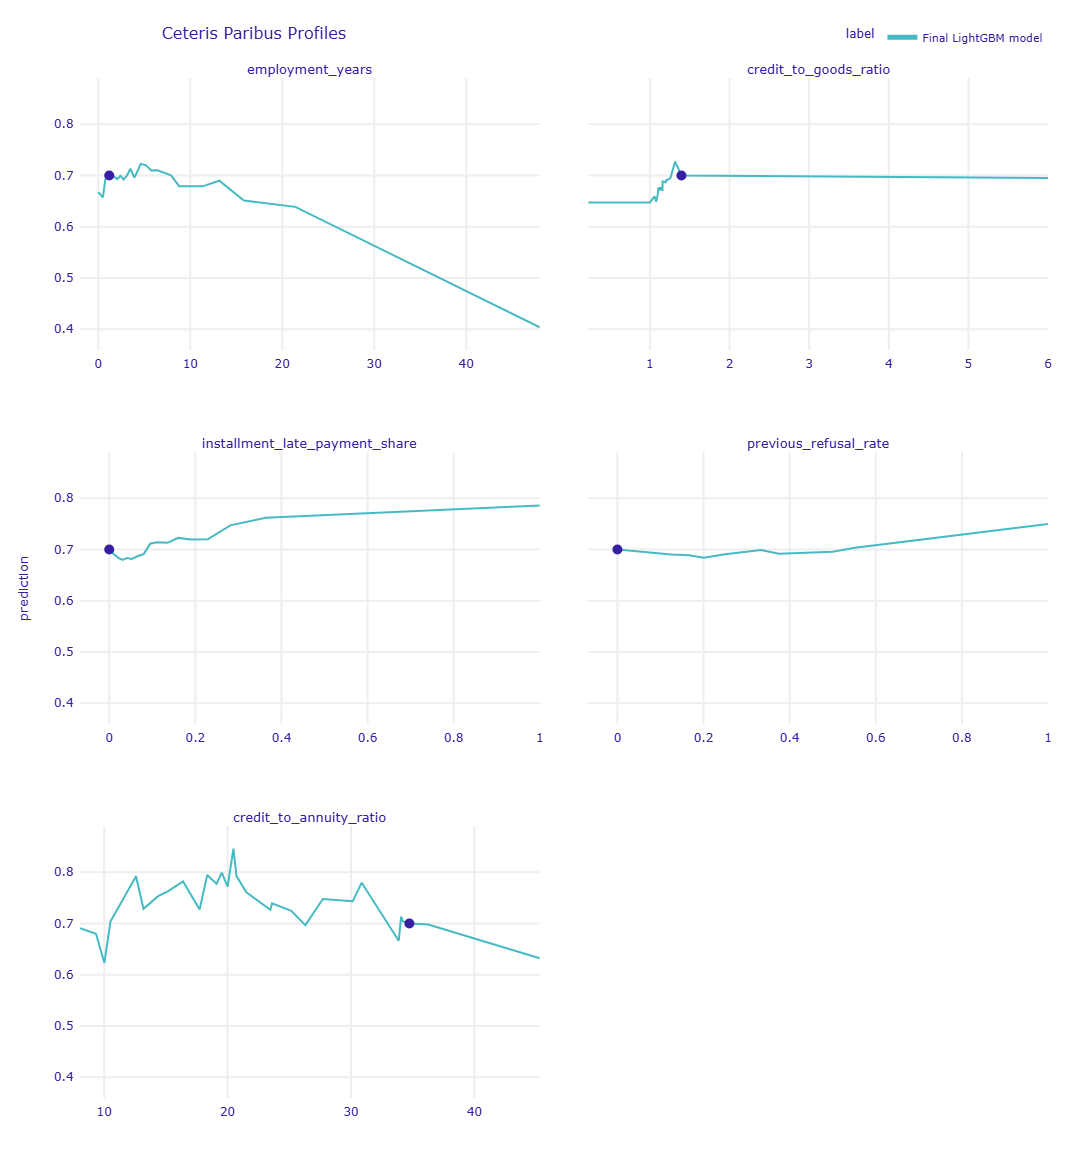

In [251]:
# DALEX Ceteris Paribus / What-if analysis for one rejected applicant

# Prefer a rejected case close to the decision threshold,
# because this is the most useful case for local counterfactual exploration.
dalex_local_cases = interesting_examples[
    interesting_examples["predicted_label"] == 1
].copy()

if "decision_margin" in dalex_local_cases.columns:
    dalex_local_cases = dalex_local_cases.sort_values("decision_margin", ascending=True)

if dalex_local_cases.empty:
    raise ValueError("No rejected cases found in interesting_examples for DALEX local analysis.")

dalex_local_case = dalex_local_cases.iloc[[0]].copy()

dalex_new_observation = (
    dalex_local_case[selected_feature_names]
    .copy()
    .apply(pd.to_numeric, errors="coerce")
)

dalex_case_sk_id = dalex_local_case["SK_ID_CURR"].iloc[0]
dalex_case_original_pd = float(dalex_predict_function(model, dalex_new_observation)[0])
dalex_case_original_label = int(dalex_case_original_pd >= decision_threshold)

print(f"Selected case for DALEX Ceteris Paribus analysis: SK_ID_CURR = {dalex_case_sk_id}")
print(f"Original predicted PD: {dalex_case_original_pd:.6f}")
print(f"Original predicted label: {dalex_case_original_label}")
print(f"Decision threshold: {decision_threshold:.6f}")

dalex_ceteris_paribus = dalex_explainer.predict_profile(
    new_observation=dalex_new_observation,
    variables=dalex_profile_variables,
    grid_points=31,
    variable_splits_type="quantiles",
    verbose=False,
)

print("DALEX Ceteris Paribus result preview:")
display(dalex_ceteris_paribus.result.head(20))

try:
    fig = dalex_ceteris_paribus.plot(show=False)
    fig.show()
except TypeError:
    dalex_ceteris_paribus.plot()

In [252]:
# Benchmark DiCE vs Alibi counterfactuals

def get_feature_ranges_for_benchmark(reference_df, feature_list):
    """
    Calculate robust ranges for distance normalization.
    Uses 1st-99th percentile range to reduce the effect of outliers.
    """
    ranges = {}

    for col in feature_list:
        values = pd.to_numeric(reference_df[col], errors="coerce").dropna()

        if values.empty:
            ranges[col] = 1.0
            continue

        q01 = float(values.quantile(0.01))
        q99 = float(values.quantile(0.99))
        span = q99 - q01

        if not np.isfinite(span) or span <= 0:
            span = float(values.max() - values.min())

        if not np.isfinite(span) or span <= 0:
            span = 1.0

        ranges[col] = span

    return ranges


def normalized_distances_from_diffs(diff_dict, feature_ranges):
    """
    Calculates L1 and L2 normalized distances from raw feature differences.
    """
    normalized_abs_diffs = []

    for col, diff in diff_dict.items():
        if diff is None or pd.isna(diff):
            continue

        scale = feature_ranges.get(col, 1.0)
        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        normalized_abs_diffs.append(abs(float(diff)) / scale)

    if len(normalized_abs_diffs) == 0:
        return 0.0, 0.0

    l1_norm = float(np.sum(normalized_abs_diffs))
    l2_norm = float(np.sqrt(np.sum(np.square(normalized_abs_diffs))))

    return l1_norm, l2_norm


benchmark_feature_ranges = get_feature_ranges_for_benchmark(
    reference_df=X_train,
    feature_list=features_to_vary,
)

cf_benchmark_rows = []

# -------------------------
# DiCE benchmark rows
# -------------------------
if "final_dice_table" in globals() and not final_dice_table.empty:

    for _, row in final_dice_table.iterrows():

        diff_dict = {}

        for col in features_to_vary:
            diff_col = f"{col}_diff"
            original_col = f"{col}_original"
            cf_col = f"{col}_cf"

            if diff_col in final_dice_table.columns:
                diff = row[diff_col]
            elif original_col in final_dice_table.columns and cf_col in final_dice_table.columns:
                diff = float(row[cf_col]) - float(row[original_col])
            else:
                diff = np.nan

            diff_dict[col] = diff

        l1_norm, l2_norm = normalized_distances_from_diffs(
            diff_dict=diff_dict,
            feature_ranges=benchmark_feature_ranges,
        )

        original_pd = float(row["original_pd"])
        cf_pd = float(row["counterfactual_pd"])
        is_valid = bool(cf_pd < decision_threshold)

        cf_benchmark_rows.append({
            "method": "DiCE",
            "SK_ID_CURR": row["SK_ID_CURR"],
            "selection_group": row.get("selection_group", "unknown"),
            "case_type": row.get("case_type", "unknown"),
            "original_pd": original_pd,
            "counterfactual_pd": cf_pd,
            "pd_reduction": original_pd - cf_pd,
            "valid_counterfactual": is_valid,
            "l0_changed_features": int(row["n_changed_features"]),
            "l1_normalized": l1_norm,
            "l2_normalized": l2_norm,
            "n_fixed_features_changed": 0,
        })


# -------------------------
# Alibi benchmark rows
# -------------------------
if "alibi_counterfactuals_df" in globals() and not alibi_counterfactuals_df.empty:

    alibi_original_lookup = (
        alibi_query_cases
        .set_index("SK_ID_CURR")
        .copy()
    )

    for _, row in alibi_counterfactuals_df.iterrows():

        sk_id = row["SK_ID_CURR"]

        if sk_id not in alibi_original_lookup.index:
            continue

        original_row = alibi_original_lookup.loc[sk_id]

        diff_dict = {}

        for col in features_to_vary:
            original_value = float(original_row[col])
            cf_value = float(row[col])
            diff_dict[col] = cf_value - original_value

        l1_norm, l2_norm = normalized_distances_from_diffs(
            diff_dict=diff_dict,
            feature_ranges=benchmark_feature_ranges,
        )

        original_pd = float(row["original_predicted_pd"])
        cf_pd = float(row["cf_predicted_pd"])
        is_valid = bool(cf_pd < decision_threshold)

        cf_benchmark_rows.append({
            "method": "Alibi",
            "SK_ID_CURR": sk_id,
            "selection_group": row.get("selection_group", "unknown"),
            "case_type": row.get("case_type", "unknown"),
            "original_pd": original_pd,
            "counterfactual_pd": cf_pd,
            "pd_reduction": original_pd - cf_pd,
            "valid_counterfactual": is_valid,
            "l0_changed_features": int(row["n_changed_features"]),
            "l1_normalized": l1_norm,
            "l2_normalized": l2_norm,
            "n_fixed_features_changed": int(row.get("n_fixed_features_changed", 0)),
        })


cf_benchmark_raw_df = pd.DataFrame(cf_benchmark_rows)

if cf_benchmark_raw_df.empty:
    print("No counterfactuals available for benchmarking.")
else:
    print("Raw counterfactual benchmark table:")
    display(cf_benchmark_raw_df.sort_values(["method", "SK_ID_CURR"]).reset_index(drop=True))

Raw counterfactual benchmark table:


,method,SK_ID_CURR,selection_group,case_type,original_pd,counterfactual_pd,pd_reduction,valid_counterfactual,l0_changed_features,l1_normalized,l2_normalized,n_fixed_features_changed
0,Alibi,237950,misclassified_default_close,false_positive,0.700308,0.693055,0.007254,True,1,0.000011,0.000011,0
1,Alibi,248647,misclassified_default_close,false_positive,0.700200,0.691886,0.008313,True,1,0.000014,0.000014,0
2,Alibi,331469,near_boundary,true_positive,0.700013,0.694525,0.005489,True,1,0.000010,0.000010,0
3,Alibi,346094,correct_default,true_positive,0.700193,0.676324,0.023870,True,1,0.000014,0.000014,0
4,Alibi,360385,near_boundary,true_positive,0.700195,0.621282,0.078913,True,1,0.000075,0.000075,0
5,Alibi,449034,near_boundary,true_positive,0.700157,0.699718,0.000439,True,1,0.000016,0.000016,0
6,DiCE,237950,misclassified_default_close,false_positive,0.700308,0.512896,0.187412,True,5,1.292336,0.747523,0
7,DiCE,346094,correct_default,true_positive,0.700193,0.491469,0.208724,True,3,0.753352,0.479744,0
8,DiCE,360385,near_boundary,true_positive,0.700195,0.456111,0.244085,True,4,2.228408,1.519513,0
9,DiCE,449034,near_boundary,true_positive,0.700157,0.500927,0.199229,True,3,0.415485,0.389156,0


DiCE vs Alibi benchmark summary:


,method,attempted_cases,n_counterfactuals_found,coverage_on_selected_cases,n_valid_counterfactuals,validity_rate_among_found,mean_original_pd,mean_counterfactual_pd,mean_pd_reduction,mean_l0_changed_features,median_l0_changed_features,mean_l1_normalized,median_l1_normalized,mean_l2_normalized,median_l2_normalized,max_fixed_features_changed
0,Alibi,12,6,0.500000,6,1.0,0.700178,0.679465,0.020713,1.00,1.0,0.000023,0.000014,0.000023,0.000014,0
1,DiCE,7,4,0.571429,4,1.0,0.700213,0.490351,0.209863,3.75,3.5,1.172395,1.022844,0.783984,0.613634,0


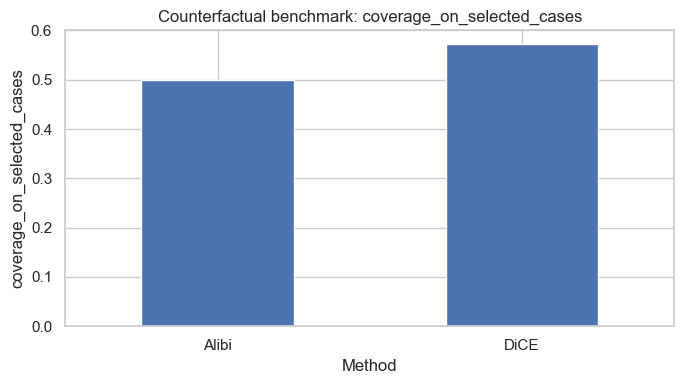

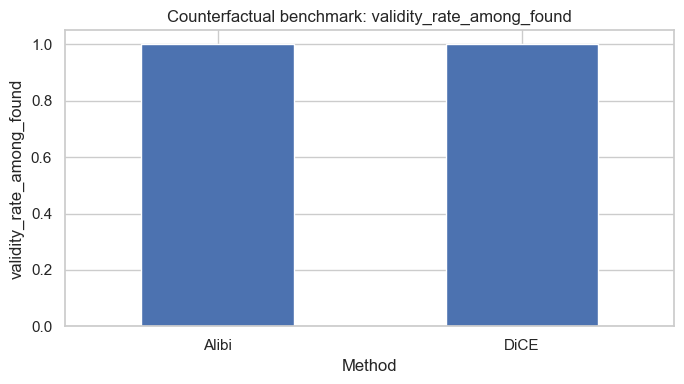

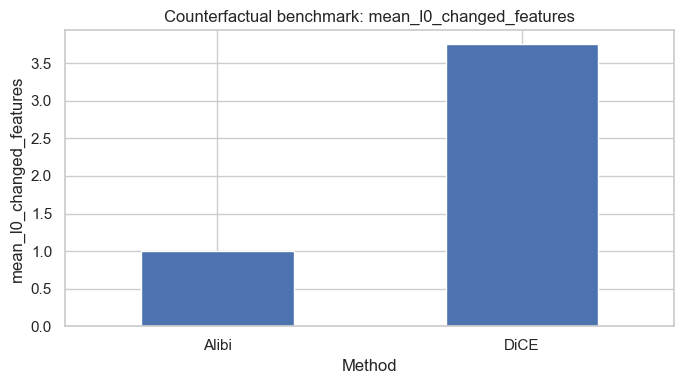

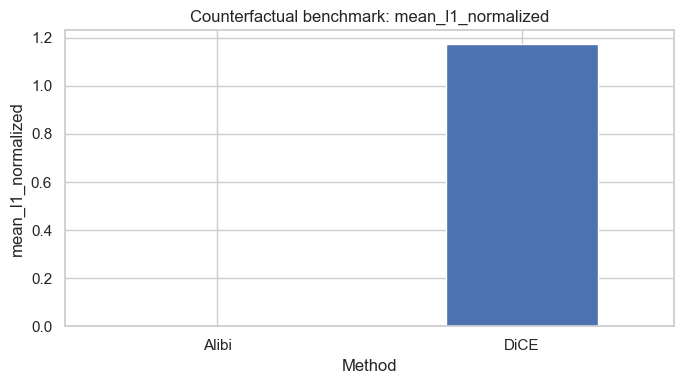

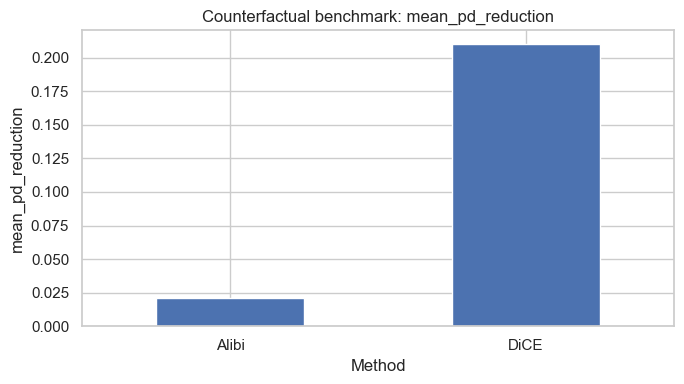

In [253]:
# Summary of DiCE vs Alibi benchmark

if cf_benchmark_raw_df.empty:
    print("No benchmark summary can be created because no counterfactual rows are available.")
else:

    # Number of attempted cases per method
    dice_attempted_cases = len(dice_log_df) if "dice_log_df" in globals() else (
        len(dice_query_cases) if "dice_query_cases" in globals() else np.nan
    )

    alibi_attempted_cases = len(alibi_log_df) if "alibi_log_df" in globals() else (
        len(alibi_query_cases) if "alibi_query_cases" in globals() else np.nan
    )

    attempted_cases_by_method = {
        "DiCE": dice_attempted_cases,
        "Alibi": alibi_attempted_cases,
    }

    cf_benchmark_summary_df = (
        cf_benchmark_raw_df
        .groupby("method")
        .agg(
            n_counterfactuals_found=("SK_ID_CURR", "count"),
            n_valid_counterfactuals=("valid_counterfactual", "sum"),
            mean_original_pd=("original_pd", "mean"),
            mean_counterfactual_pd=("counterfactual_pd", "mean"),
            mean_pd_reduction=("pd_reduction", "mean"),
            mean_l0_changed_features=("l0_changed_features", "mean"),
            median_l0_changed_features=("l0_changed_features", "median"),
            mean_l1_normalized=("l1_normalized", "mean"),
            median_l1_normalized=("l1_normalized", "median"),
            mean_l2_normalized=("l2_normalized", "mean"),
            median_l2_normalized=("l2_normalized", "median"),
            max_fixed_features_changed=("n_fixed_features_changed", "max"),
        )
        .reset_index()
    )

    cf_benchmark_summary_df["attempted_cases"] = (
        cf_benchmark_summary_df["method"].map(attempted_cases_by_method)
    )

    cf_benchmark_summary_df["coverage_on_selected_cases"] = (
        cf_benchmark_summary_df["n_counterfactuals_found"]
        / cf_benchmark_summary_df["attempted_cases"]
    )

    cf_benchmark_summary_df["validity_rate_among_found"] = (
        cf_benchmark_summary_df["n_valid_counterfactuals"]
        / cf_benchmark_summary_df["n_counterfactuals_found"]
    )

    cf_benchmark_summary_df = cf_benchmark_summary_df[
        [
            "method",
            "attempted_cases",
            "n_counterfactuals_found",
            "coverage_on_selected_cases",
            "n_valid_counterfactuals",
            "validity_rate_among_found",
            "mean_original_pd",
            "mean_counterfactual_pd",
            "mean_pd_reduction",
            "mean_l0_changed_features",
            "median_l0_changed_features",
            "mean_l1_normalized",
            "median_l1_normalized",
            "mean_l2_normalized",
            "median_l2_normalized",
            "max_fixed_features_changed",
        ]
    ]

    print("DiCE vs Alibi benchmark summary:")
    display(cf_benchmark_summary_df)

    plot_df = cf_benchmark_summary_df.set_index("method")

    metrics_to_plot = [
        "coverage_on_selected_cases",
        "validity_rate_among_found",
        "mean_l0_changed_features",
        "mean_l1_normalized",
        "mean_pd_reduction",
    ]

    for metric in metrics_to_plot:
        plt.figure(figsize=(7, 4))
        plot_df[metric].plot(kind="bar")
        plt.title(f"Counterfactual benchmark: {metric}")
        plt.ylabel(metric)
        plt.xlabel("Method")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

In [254]:
# Save DALEX and benchmark results

evaluation_output_dir = MODELS_DIR / "evaluation_benchmarking"
evaluation_output_dir.mkdir(parents=True, exist_ok=True)

# DALEX variable importance
dalex_variable_importance_table.to_csv(
    evaluation_output_dir / "dalex_variable_importance.csv",
    index=False,
)

# DALEX Ceteris Paribus result
dalex_ceteris_paribus.result.to_csv(
    evaluation_output_dir / "dalex_ceteris_paribus_profiles.csv",
    index=False,
)

# Best one-dimensional what-if points
if "dalex_best_what_if_table" in globals():
    dalex_best_what_if_table.to_csv(
        evaluation_output_dir / "dalex_best_what_if_points.csv",
        index=False,
    )

# Counterfactual benchmark raw and summary tables
if "cf_benchmark_raw_df" in globals() and not cf_benchmark_raw_df.empty:
    cf_benchmark_raw_df.to_csv(
        evaluation_output_dir / "counterfactual_benchmark_raw.csv",
        index=False,
    )

if "cf_benchmark_summary_df" in globals() and not cf_benchmark_summary_df.empty:
    cf_benchmark_summary_df.to_csv(
        evaluation_output_dir / "counterfactual_benchmark_summary.csv",
        index=False,
    )

print(f"Evaluation and benchmarking results saved to: {evaluation_output_dir}")

Evaluation and benchmarking results saved to: C:\wb_allegro\models\evaluation_benchmarking


# 9. Summary & Next Steps

## What we have done:

In the first part of the project, we built a binary classification pipeline for the Home Credit dataset using a LightGBM model.

We started with basic data preparation and exploration of the main application table. We checked the target distribution, missing values, selected correlations, and distributions of the most important variables. This helped us understand the dataset and spot variables that looked useful for modeling.

Then we moved to feature engineering. Besides the original application variables, we used the supplementary tables such as `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `POS_CASH_balance`, and `credit_card_balance`. We aggregated them to the loan level and created more interpretable features related to credit burden, repayment history, previous applications, and external scores.

After that, we handled missing values and encoded categorical variables. We tried to keep preprocessing consistent with both the final model and the later counterfactual analysis.

For feature selection, we used Boruta and then reduced selected variables by keeping only variables with low correlation between each other. Based on that, we selected a smaller and more interpretable final feature set.

The final model for this part was LightGBM. We also briefly compared it with XGBoost, but it did not improve the results, so we kept LightGBM as the final choice and removed the XGBoost part from the final workflow. We also performed hyperparameter tuning with cross-validation to improve the model settings.

Next, using the given rating masterscale based on predicted probabilities, we chose the decision threshold. The final threshold was set at the boundary between ratings C and D, which classified about **11% of applicants as bad**. This matches the requirement that around 10% of applicants should be classified as defaults.

We then evaluated the model using ROC-AUC, accuracy, balanced accuracy, precision, recall, F1-score, confusion matrix, and SHAP analysis. The ROC-AUC was around **0.77**, which suggests that the model has a reasonable ability to separate good and bad applicants. The SHAP summary plot showed that the model was driven mainly by external risk scores, credit burden ratios, repayment behavior, and variables describing previous credit history.

Finally, we prepared the counterfactual-analysis setup using **DiCE** and **Alibi**. We selected a diversified group of interesting rejected cases, defined immutable and mutable features, and generated compact counterfactual summaries showing what minimal feature changes would be needed to move a case to the good side of the threshold. In the Alibi implementation, only selected mutable features were allowed to change, while all fixed features were copied from the original observation before scoring the counterfactual with the final LightGBM model.

Lastly, we prepared DALEX evaluation and benchmarking to compare DICE and Alibi results. We saved the results to **models\evaluation_benchmarking
**.

---

## AI Tools Used

| Tool | How it was used |
|---|---|
| ChatGPT | Helped us understand the Home Credit tables and structure the early data exploration. |
| ChatGPT | Helped refine feature engineering ideas and make feature names more interpretable. |
| ChatGPT | Helped troubleshoot and simplify Boruta feature selection, including memory issues and correlation-based filtering. |
| ChatGPT | Helped set up and adjust the LightGBM hyperparameter search space and compare it with XGBoost. |
| ChatGPT | Helped prepare the distribution of predicted probabilities and choose the threshold using the masterscale. |
| ChatGPT | Helped set up the counterfactual workflow for DiCE and Alibi, because these packages were new to us, and organize the final counterfactual summary tables. |
| ChatGPT | Prepare the DALEX evaluation and benchmarking |